In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib
import qRegNN as qrnn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torchsummary import summary

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


In [2]:
a = np.array([[1,2],[3,4]])
a.repeat(2,axis=0)

array([[1, 2],
       [1, 2],
       [3, 4],
       [3, 4]])


# Load Data & Bkg

In [3]:
year = 2017
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi']
data,unnorm_data,mass_data,names = hf.LAPS_train("DATA",year,num_batches=5,Mjj_cut=800,pt_cut=300,additional=additional_vars)
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=-1,Mjj_cut=800,pt_cut=300,additional=additional_vars)

# normalize to data mean/std
mean = data.mean(axis=0)
std = data.std(axis=0)

data = (data-mean)/std
bkg = (bkg-mean)/std

np.save("QR_models/data.npy",data)
np.save("QR_models/bkg.npy",bkg)

del data, bkg

In [3]:
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi']
year=2017
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=1,Mjj_cut=800,pt_cut=300,additional=additional_vars)
del bkg,unnorm_bkg,mass_bkg
data = np.load("QR_models/data.npy")
bkg = np.load("QR_models/bkg.npy")

In [4]:
j1_varDict = {"pt":"jet1_pt",
              "eta":"jet1_eta",
              "phi":"jet1_phi",
              "m":r"$M_{j1}$",
              "tau21":r"Jet 1 $\tau_{21}$",
              "tau32":r"Jet 1 $\tau_{32}$",
              "tau43":r"Jet 1 $\tau_{43}$",
              "tauS":r"Jet 1 $\tau_s$",
              "pb":r"Jet 1 $P_b$",
              "npf":r"Jet 1 $n_{pf}$"}

j2_varDict = {"pt":"jet2_pt",
              "eta":"jet2_eta",
              "phi":"jet2_phi",
              "m":r"$M_{j2}$",
              "tau21":r"Jet 2 $\\tau_{21}$",
              "tau32":r"Jet 2 $\\tau_{32}$",
              "tau43":r"Jet 2 $\\tau_{43}$",
              "tauS":r"Jet 2 $\\tau_s$",
              "pb":r"Jet 2 $P_b$",
              "npf":r"Jet 2 $n_{pf}$"}

xlims = {
    "pt":[-2.5,10],
    "eta":[-2.5,2.5],
    "phi":[-2,2],
    "m":[-2,10],
    "tau21":[-3.5,3],
    "tau32":[-8,4],
    "tau43":[-10,6],
    "tauS":[-3,15],
    "pb":[-6,4],
    "npf":[-3,8]
}

def getQuantiles(arr,num=30,lo=0.0001,hi=0.9999):
    from scipy.stats import percentileofscore
    x0 = np.quantile(arr,lo)
    x1 = np.quantile(arr,hi)
    spaces = np.linspace(x0,x1,num=num)
    qs = []
    for s in spaces:
        qs.append(np.mean(arr<=s))
    qs = np.array(qs)
    return qs[qs>0]

def makeQList(arr,edges,nums):
    qs = []
    for i in range(len(edges)-1):
        q = getQuantiles(arr,lo=edges[i],hi=edges[i+1],num=nums[i])
        if i == len(edges)-2:
            qs.append(q)
        else:
            qs.append(q[:-1])
    return np.concatenate(qs)

# Look at variables

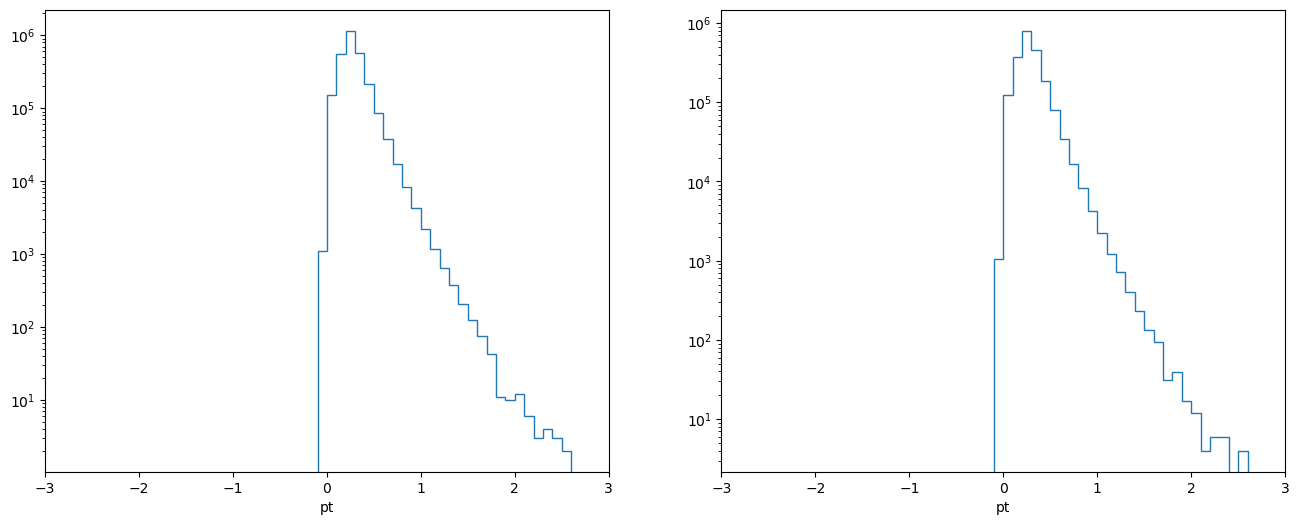

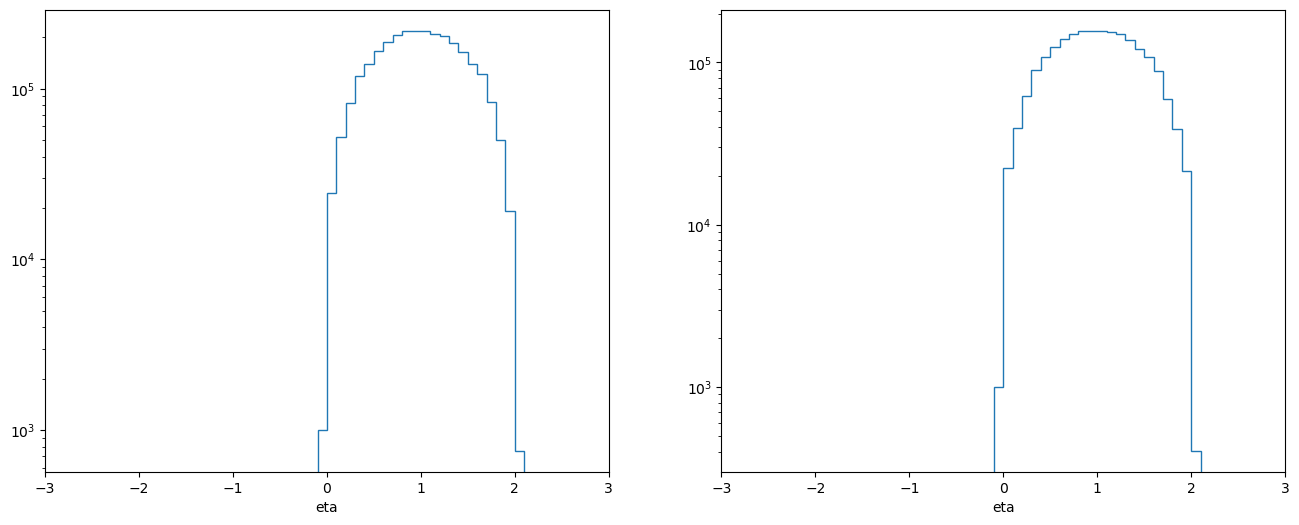

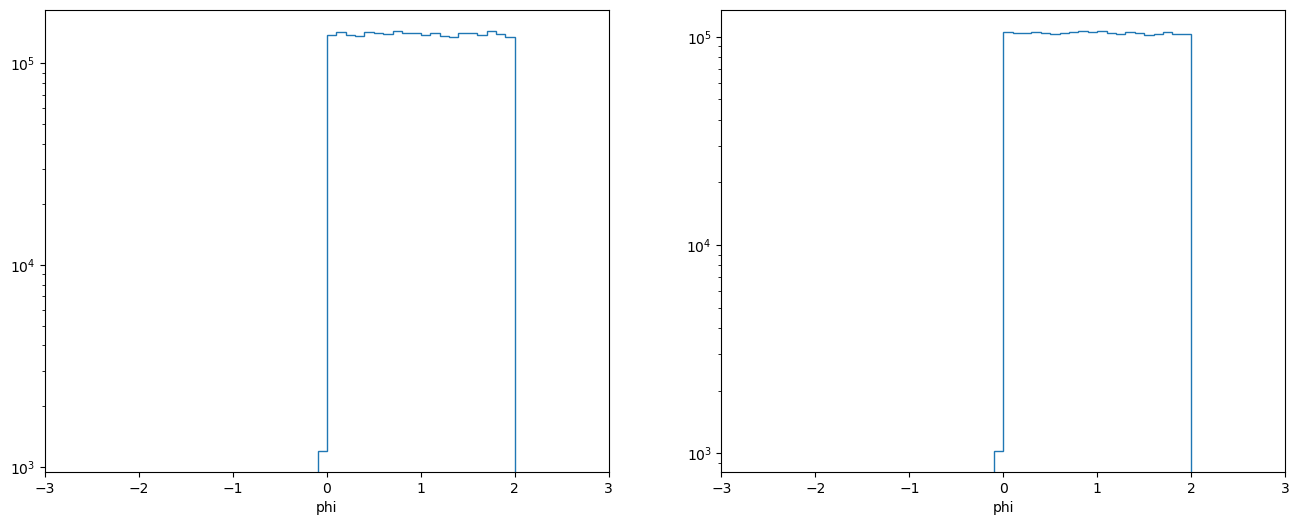

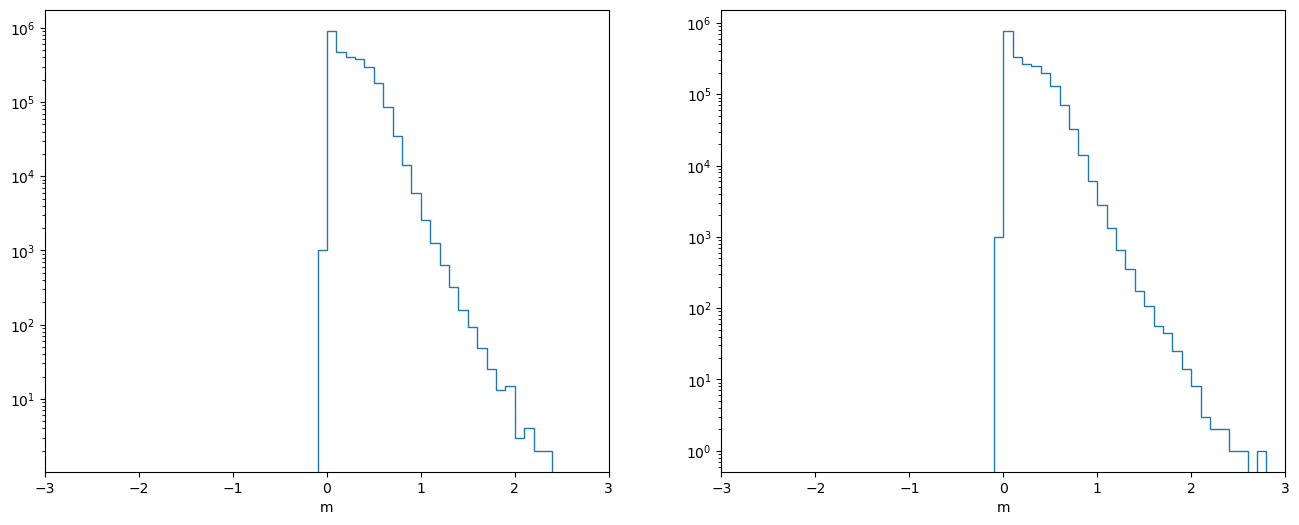

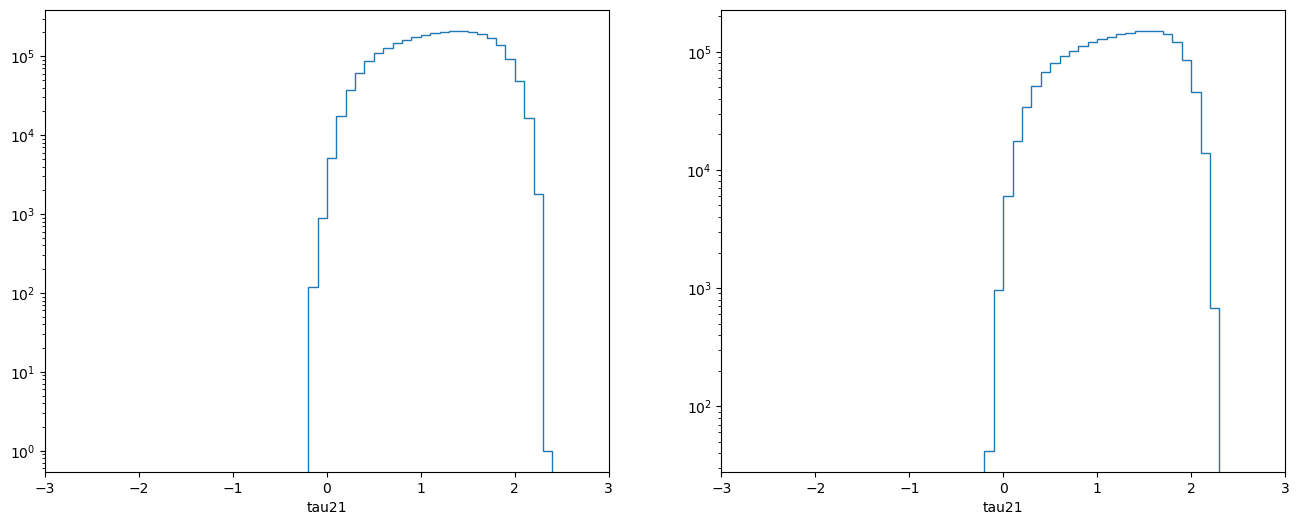

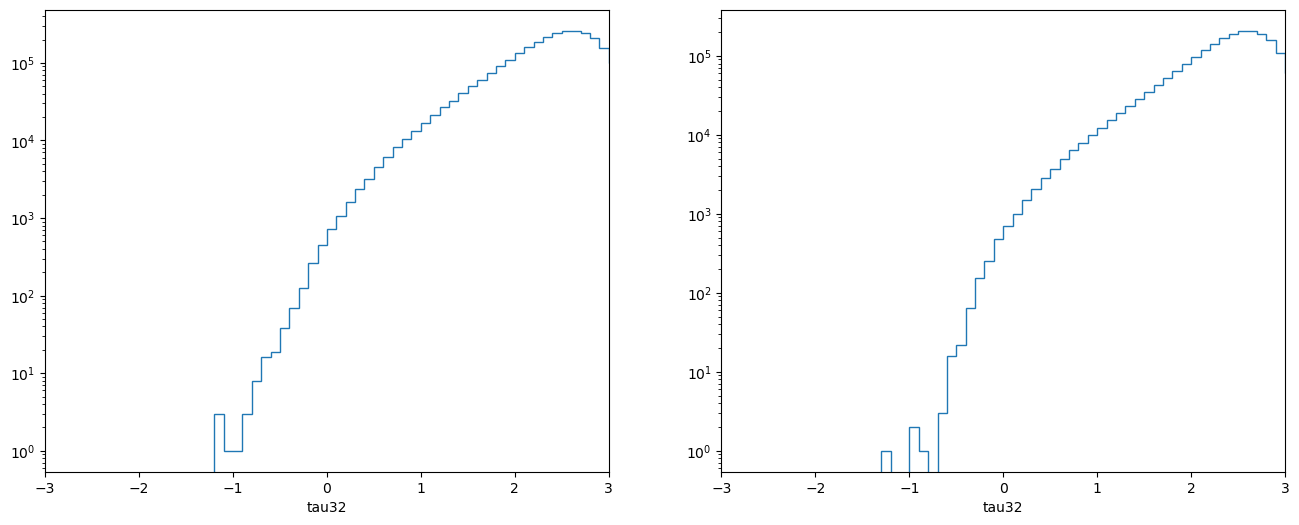

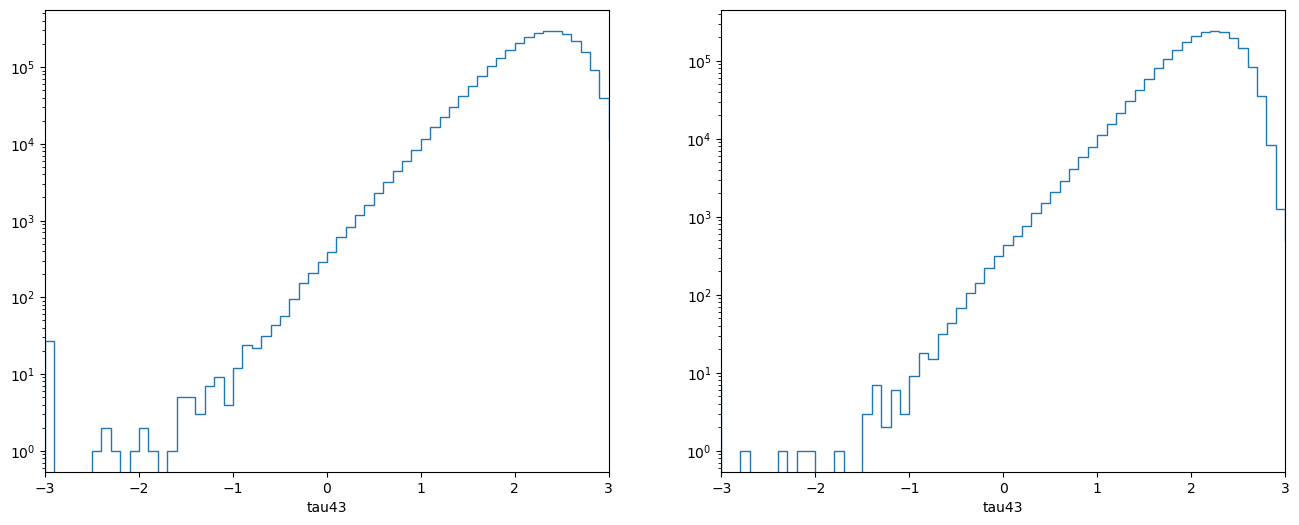

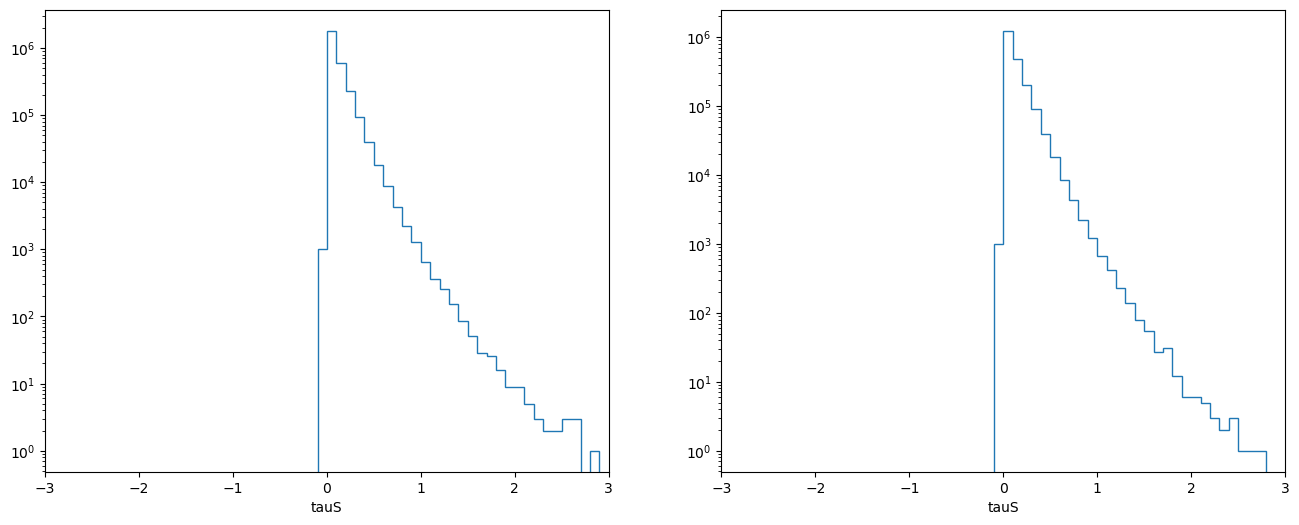

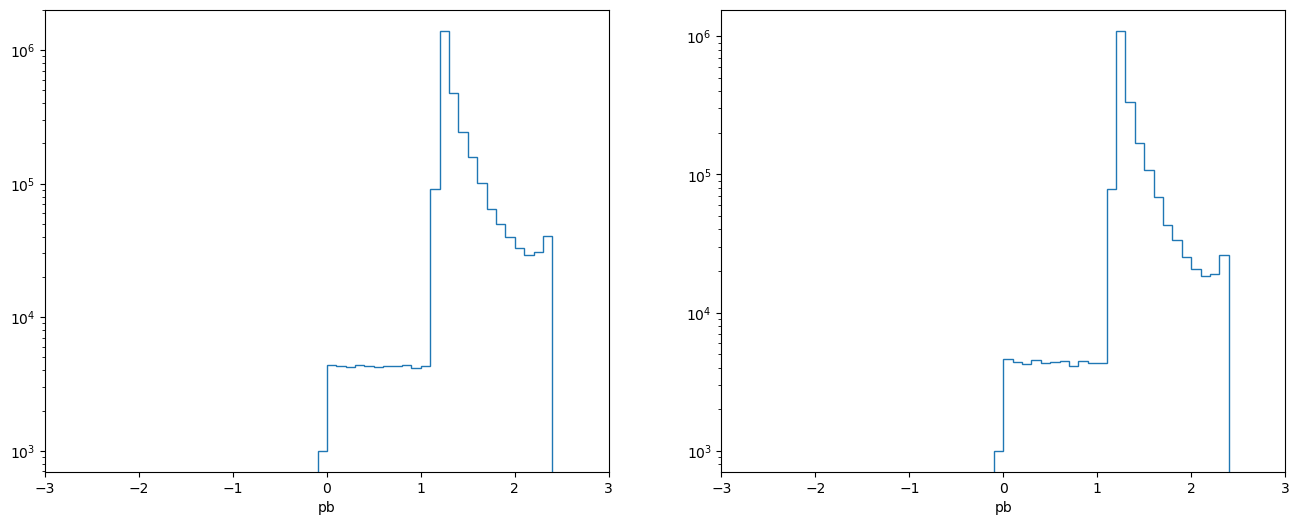

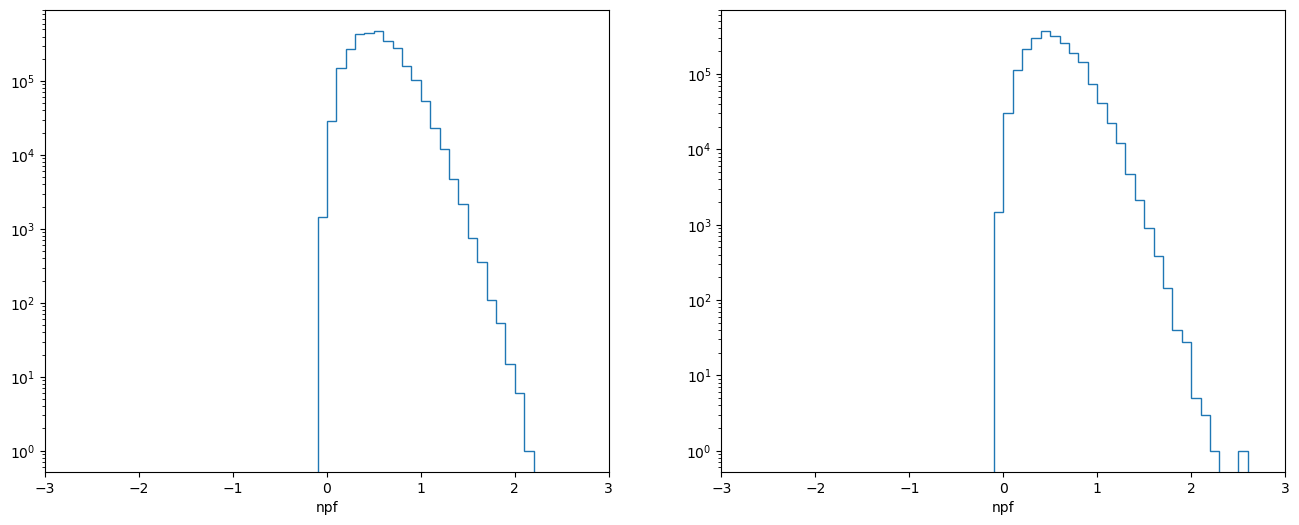

In [193]:
for var in j1_varDict.keys():
    ind = names.index(j1_varDict[var])
    xlim = xlims[var]
    plt.figure(figsize=(16,6))
    plt.subplot(121)
    h = plt.hist(data[:,ind],bins=np.arange(-20,20.1,0.1),histtype='step')
    plt.xlabel(var)
    plt.yscale('log')
    plt.xlim(xlim)
    plt.subplot(122)
    h = plt.hist(bkg[:,ind],bins=np.arange(-20,20.1,0.1),histtype='step')
    plt.xlabel(var)
    plt.yscale('log')
    plt.xlim(xlim)

# Train NN to reweight pt, eta, phi from MC --> data

In [51]:
class classifier(nn.Module):
    def __init__(self,input_dim,widths=[30,30,30],act=nn.ReLU(),final_act=nn.Sigmoid()):
        super().__init__()
        layers = [nn.Linear(input_dim,widths[0]),act]
        for i in range(len(widths)-1):
            layers.append(nn.Linear(widths[i],widths[i+1]))
            layers.append(act)
        layers.append(nn.Linear(widths[-1],1))
        layers.append(final_act)
        self.transform = nn.Sequential(*layers)

    def forward(self,x):
        return self.transform(x)

In [94]:
data_kin = np.concatenate((data[:,names.index("jet1_pt")].reshape(-1,1),
                           data[:,names.index("jet1_eta")].reshape(-1,1),
                           data[:,names.index("jet1_phi")].reshape(-1,1)),axis=1)
bkg_kin = np.concatenate((bkg[:,names.index("jet1_pt")].reshape(-1,1),
                           bkg[:,names.index("jet1_eta")].reshape(-1,1),
                           bkg[:,names.index("jet1_phi")].reshape(-1,1)),axis=1)
data_labels = np.ones((len(data_kin),1),dtype='float32')
bkg_labels = np.zeros((len(bkg_kin),1),dtype='float32')

X = torch.tensor(np.concatenate((data_kin,bkg_kin),axis=0)).to(device)
Y = torch.tensor(np.concatenate((data_labels,bkg_labels),axis=0)).to(device)
perm = torch.randperm(len(X))
X = X[perm]
Y = Y[perm]

Epoch 0, loss = 0.7074875831604004
Epoch 100, loss = 0.6949187517166138
Epoch 200, loss = 0.6866132616996765
Epoch 300, loss = 0.6831916570663452
Epoch 400, loss = 0.683761477470398
Epoch 500, loss = 0.6841689348220825
Epoch 600, loss = 0.6809150576591492
Epoch 700, loss = 0.6829303503036499
Epoch 800, loss = 0.6808485388755798
Epoch 900, loss = 0.6818760633468628


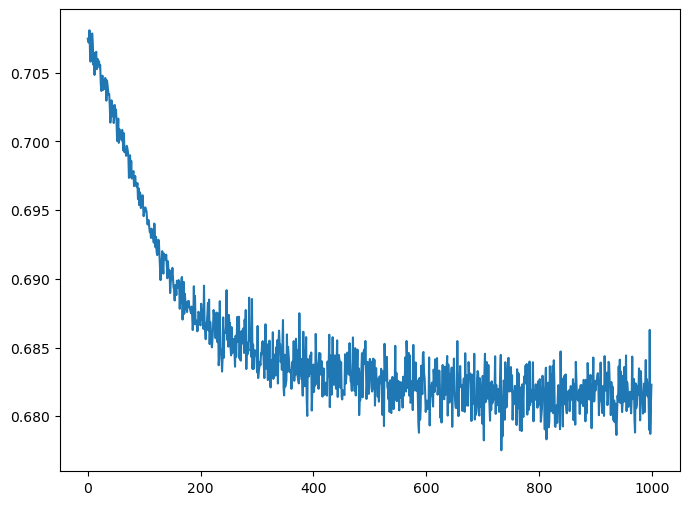

In [96]:
n_epoch = 1000
nTrain = 100000
bs = 10000
bce = nn.BCELoss()
model = classifier(X.shape[1],widths=[30,30,30]).to(device)
optimizer = optim.Adam(model.parameters(),lr=1e-5)

p = torch.randperm(len(X))
Xtrain = X[p][:nTrain]
Ytrain = Y[p][:nTrain]
minLoss = 999999
losses=[]
for i in range(n_epoch):
    perms = torch.randperm(len(Xtrain)).split(bs)
    for perm in perms:
        Xb = Xtrain[perm]
        Yb = Ytrain[perm]
        Yp = model(Xb)
        loss = bce(Yp,Yb)
        if loss.detach().cpu().numpy() < minLoss:
            minLoss = loss.detach().cpu().numpy()
            torch.save(model,"QR_models/data_bkg_kin_NN.pt")
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        del Yp
    losses.append(loss.detach().cpu().numpy())
    if i%100 == 0:
        print("Epoch {0}, loss = {1}".format(i,loss.detach().cpu().numpy()))
plt.figure(figsize=(8,6))
plt.plot(np.arange(len(losses)),losses)

In [118]:
model = torch.load("QR_models/data_bkg_kin_NN.pt").to(device)
pd = model(torch.tensor(bkg_kin).to(device)).detach().cpu().numpy()[:,0]
pmc = 1-pd
w = (pd/pmc)

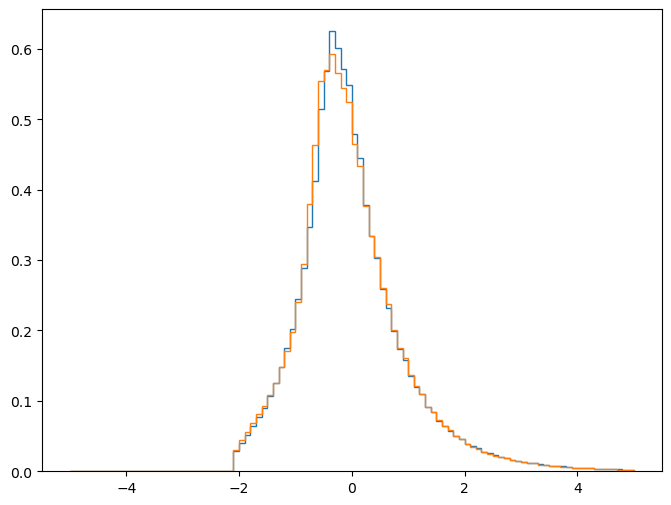

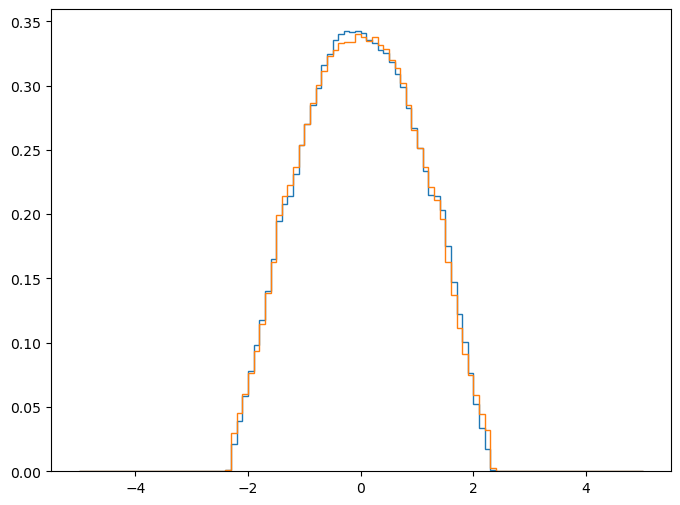

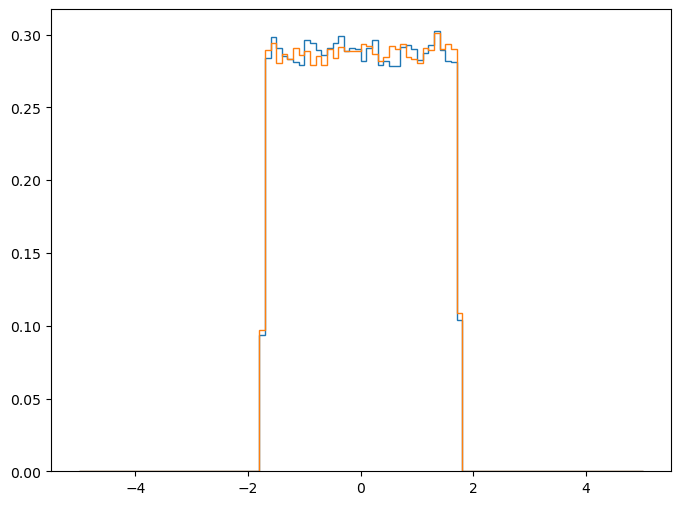

In [120]:
#bkg_kin_rw = bkg_kin*w
for i in range(3):
    plt.figure(figsize=(8,6))
    d = data_kin[:,i]
    b = bkg_kin[:,i]
    #brw = bkg_kin_rw[:,i]
    h1 = plt.hist(d,bins=np.arange(-5,5.1,0.1),histtype='step',density=True)
    #h2 = plt.hist(b,bins=np.arange(-8,8.1,0.1),histtype='step',density=True)
    h3 = plt.hist(b,weights=w,bins=np.arange(-5,5.1,0.1),histtype='step',density=True)

# Check out covariance

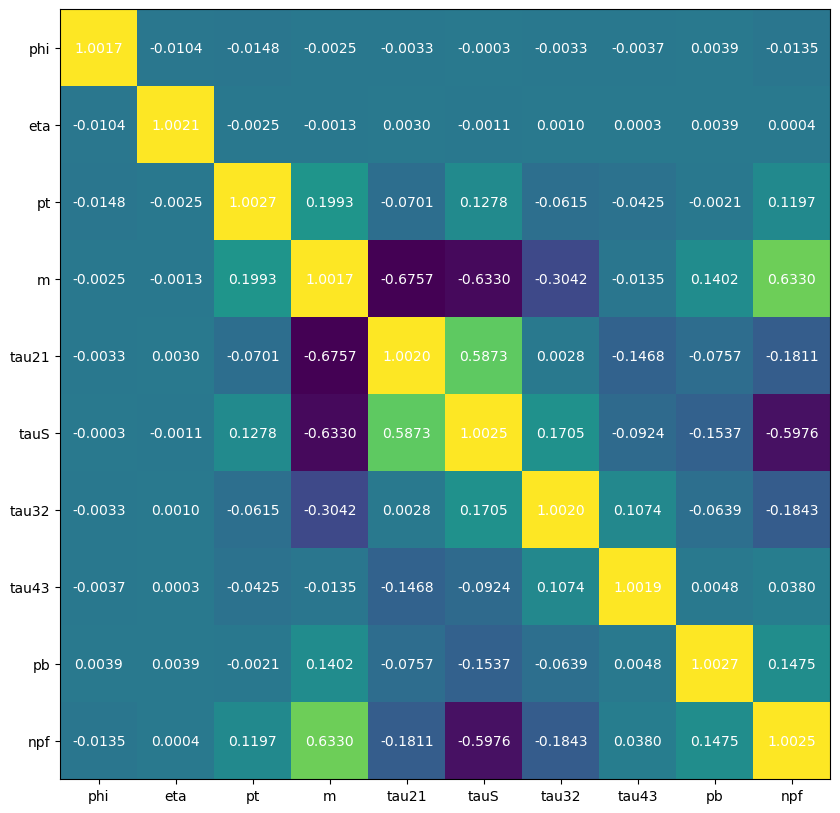

In [232]:
covVars = ["phi","eta","pt","m","tau21","tauS","tau32","tau43","pb","npf"]
data_j1 = np.concatenate([data[:,names.index(j1_varDict[v])].reshape(-1,1) for v in covVars],axis=1).T
covmat = np.cov(data_j1)
plt.figure(figsize=(10,10))
plt.imshow(covmat)
#plt.colorbar()
xt = plt.xticks(ticks=np.arange(len(covVars)),labels=covVars)
yt = plt.yticks(ticks=np.arange(len(covVars)),labels=covVars)
for (j,i),label in np.ndenumerate(covmat):
    plt.gca().text(i,j,"{0:.4f}".format(label),ha='center',va='center',color='white')

In [236]:
sums = np.sum(np.abs(covmat),axis=1)
ordered = [covVars[i] for i in np.argsort(sums)]
print(ordered)

['eta', 'phi', 'tau43', 'pb', 'pt', 'tau32', 'tau21', 'npf', 'tauS', 'm']


# Correct mass last

In [5]:
inds = {var:names.index(j1_varDict[var]) for var in j1_varDict.keys()}
qDict = {}

qDict["eta"] = makeQList(data[:,inds["eta"]],[0.01,0.99],[15])
qDict["m"] = makeQList(data[:,inds["m"]],[0.01,0.99],[10])
qDict["tauS"] = makeQList(data[:,inds["tauS"]],[0.01,0.999],[10])
qDict["tau21"] = makeQList(data[:,inds["tau21"]],[0.001,0.9999],[20])
qDict["tau32"] = makeQList(data[:,inds["tau32"]],[0.01,0.9999],[20])
qDict["tau43"] = makeQList(data[:,inds["tau43"]],[0.01,0.9999],[20])

In [7]:
j1_order = ["phi","eta","m","tauS","tau21","tau32","tau43"]
widths = [(20,3),(20,3),(30,3),(30,3),(30,3),(30,3)]
quantile_order = [np.array(qDict[var]) for var in j1_order[1:]]
trainer = qrnn.chainedTrainer(data,bkg,names,j1_order,j1_varDict,widths,quantile_order,
                              act=nn.SELU(),final_act=nn.Identity(),final_scale=1,
                              alpha=2.0,xlims=xlims)
kwargs = {"nTrain":1000000,"bs":100000,"batched":True,"n_epoch":400,"lr":5e-3,"correctFirst":True}

Current variable: eta
---------- Training Data, eta ----------
stopping early at epoch 93
0  Events with bad quantiles ( 0.0  %)
	 0  from bkg ( 0.0  %)
	 0  from data ( 0.0  %)
1030  Underflow ( 0.049315260008723535  %)
1104  Overflow ( 0.052858298106437655  %)
---------- Training Bkg, eta ----------
stopping early at epoch 88
0  Events with bad quantiles ( 0.0  %)
	 0  from bkg ( 0.0  %)
	 0  from data ( 0.0  %)
2158  Underflow ( 0.10332265155225766  %)
2063  Overflow ( 0.09877415669708413  %)


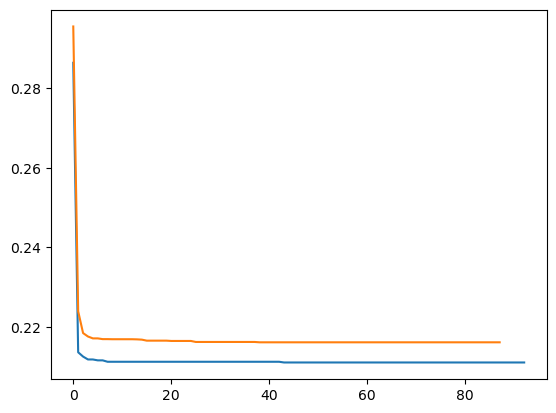

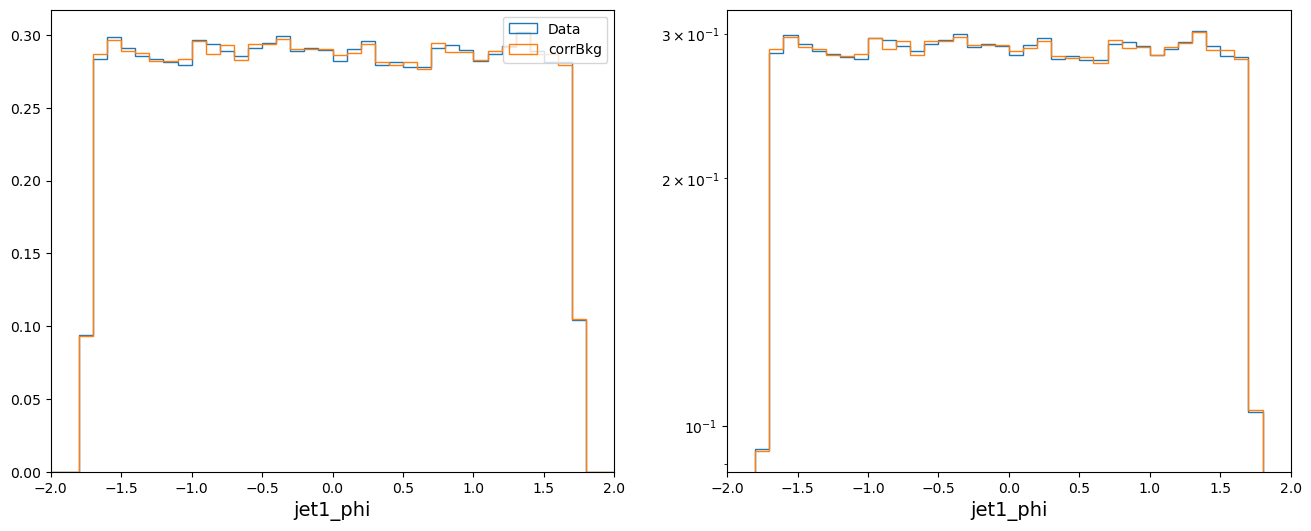

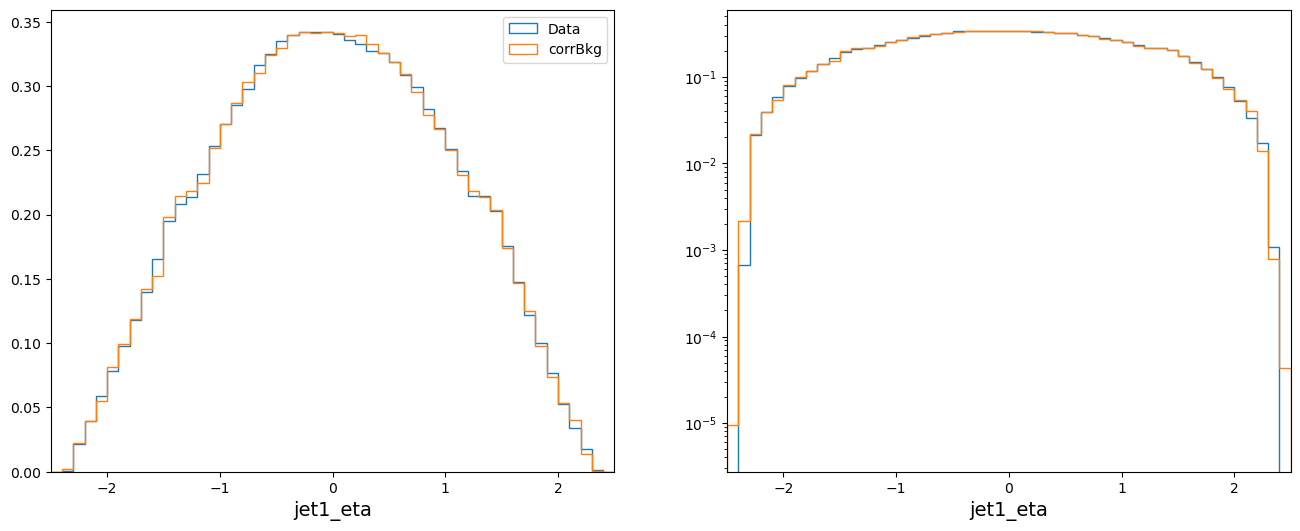

In [17]:
kcurr = kwargs
kcurr['nTrain'] = 2000000
kcurr['bs'] = 100000
trainer.stepTo("eta")
trainer.changeQuantile("eta",makeQList(data[:,inds["eta"]],[0.001,0.999],[20]))
trainer.changeWidth("eta",(20,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

Current variable: m
---------- Training Data, m ----------
Epoch 100, Loss: 0.1714021765635629
stopping early at epoch 126
---------- Training Bkg, m ----------
Epoch 100, Loss: 0.16805381958698185
stopping early at epoch 147
0  Events with bad quantiles ( 0.0  %)
	 0  from bkg ( 0.0  %)
	 0  from data ( 0.0  %)
19265  Underflow ( 0.9223868777359795  %)
2051  Overflow ( 0.0981996099785359  %)


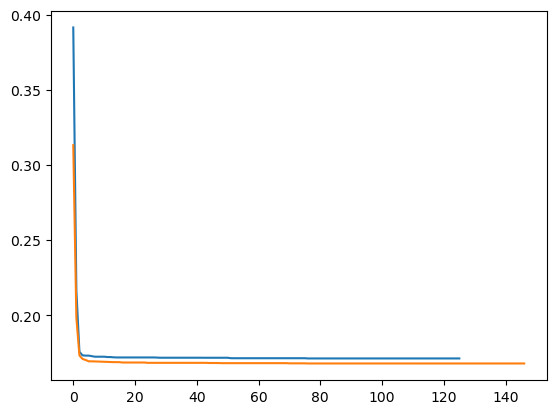

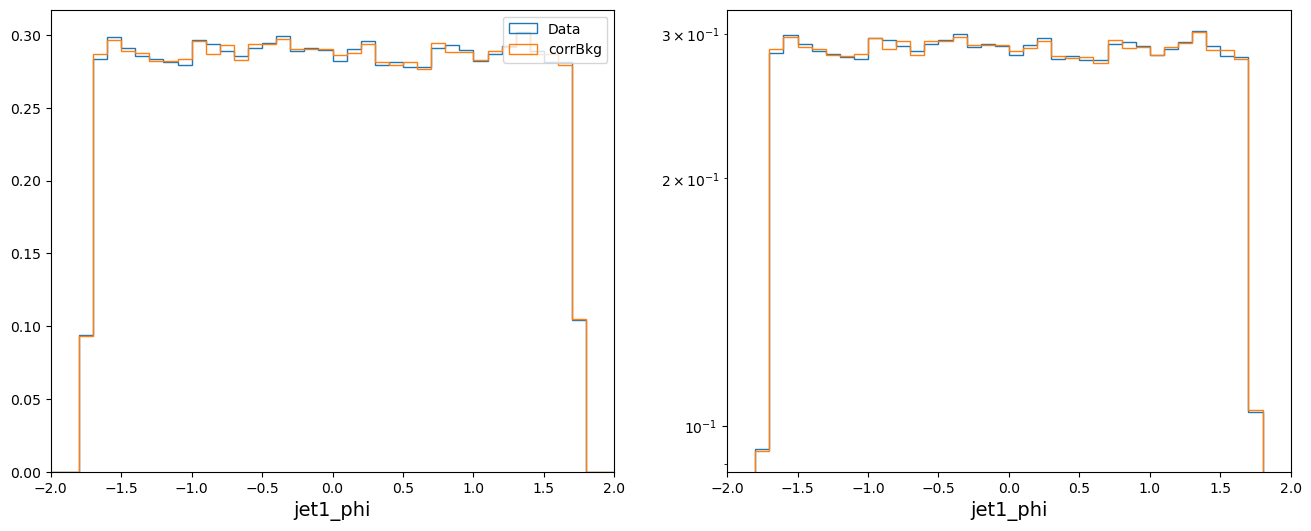

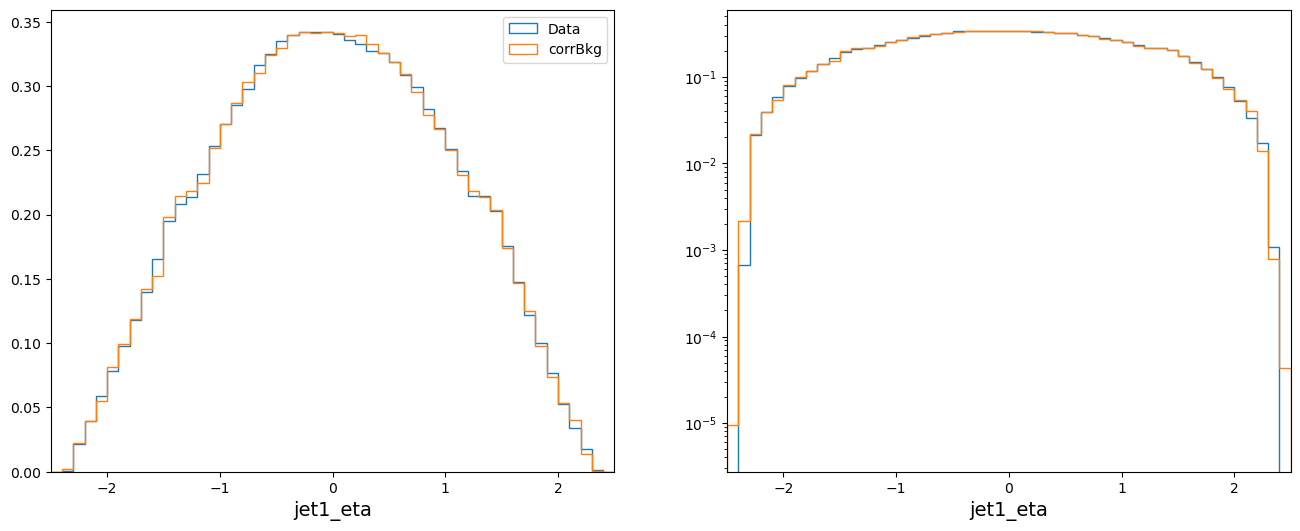

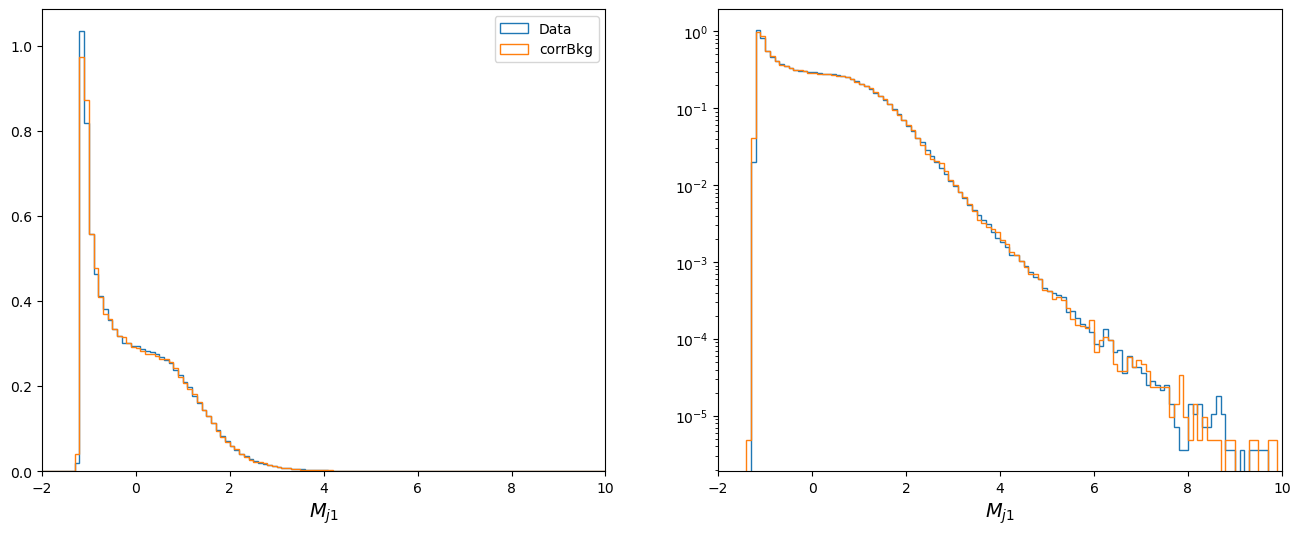

In [19]:
trainer.stepTo("m")
trainer.changeQuantile("m",makeQList(data[:,inds["m"]],[0.01,0.999],[20]))
trainer.changeWidth("m",(20,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

Current variable: tauS
---------- Training Data, tauS ----------
Epoch 100, Loss: 0.041409621794653094
stopping early at epoch 197
---------- Training Bkg, tauS ----------
Epoch 100, Loss: 0.047772577309773245
Epoch 200, Loss: 0.04741693441545353
stopping early at epoch 205
628  Events with bad quantiles ( 0.03006794493735765  %)
	 4  from bkg ( 0.00019151557284941177  %)
	 627  from data ( 0.030020066044145297  %)
22870  Underflow ( 1.0949902877665119  %)
2013  Overflow ( 0.09638021203646648  %)


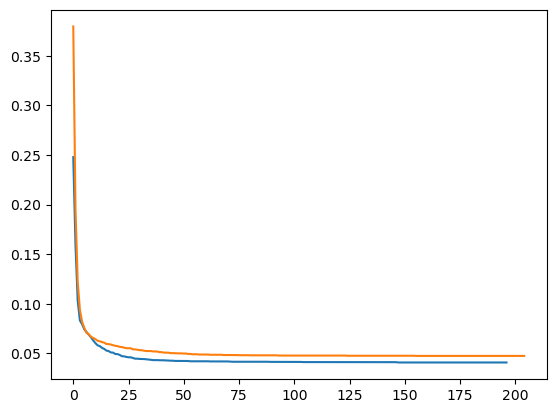

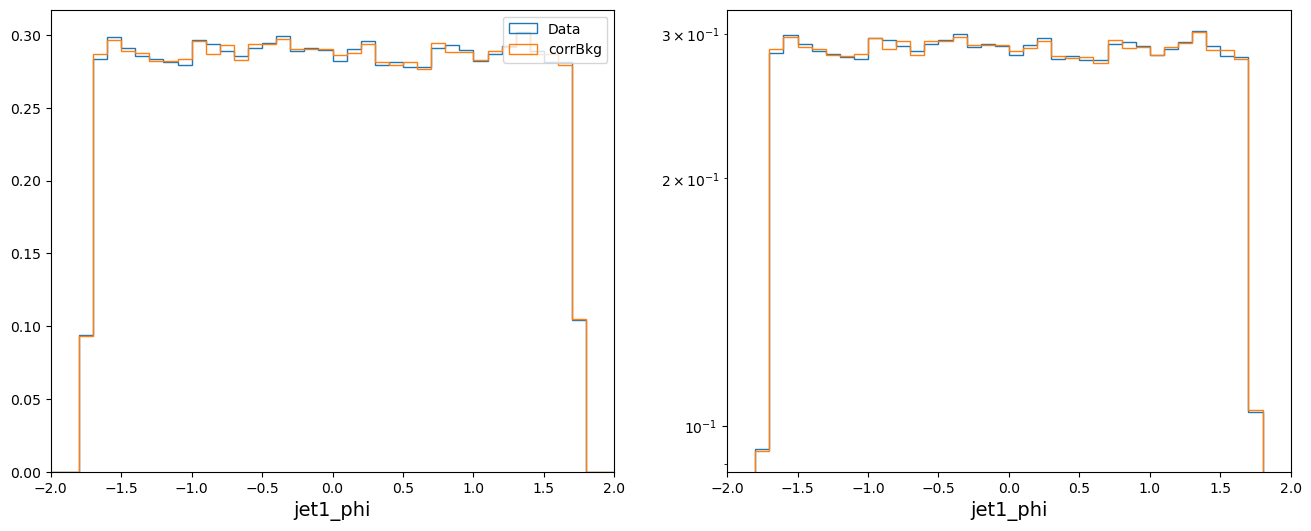

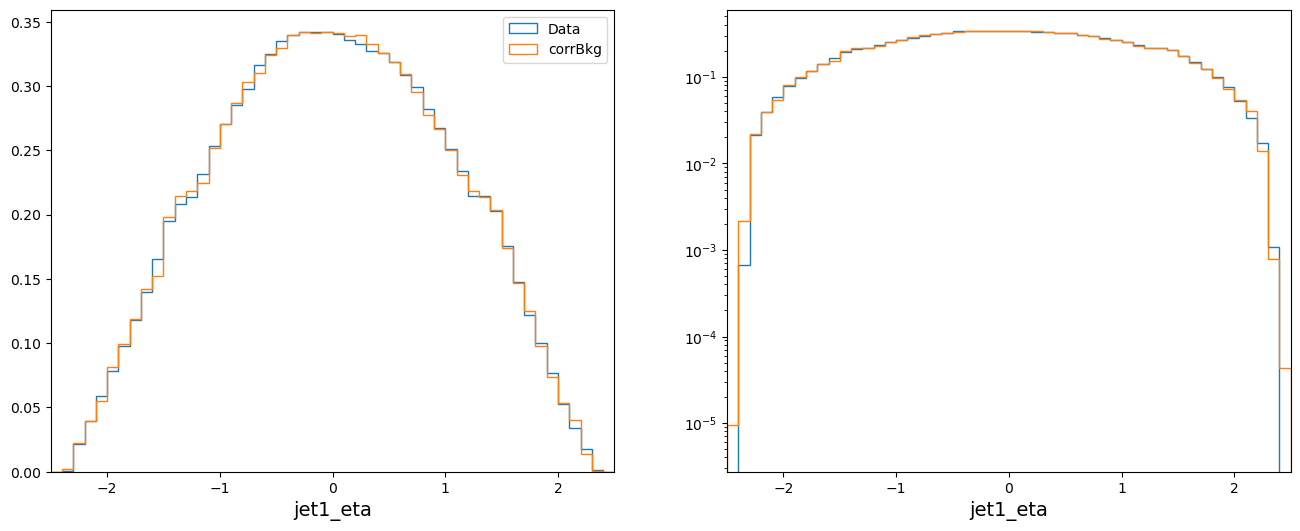

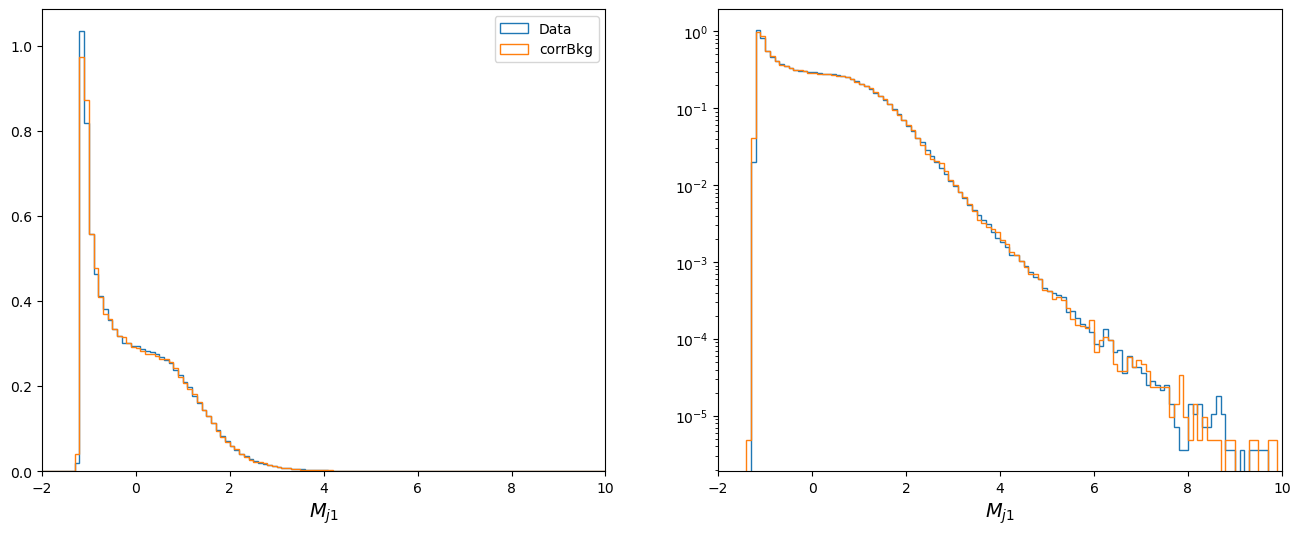

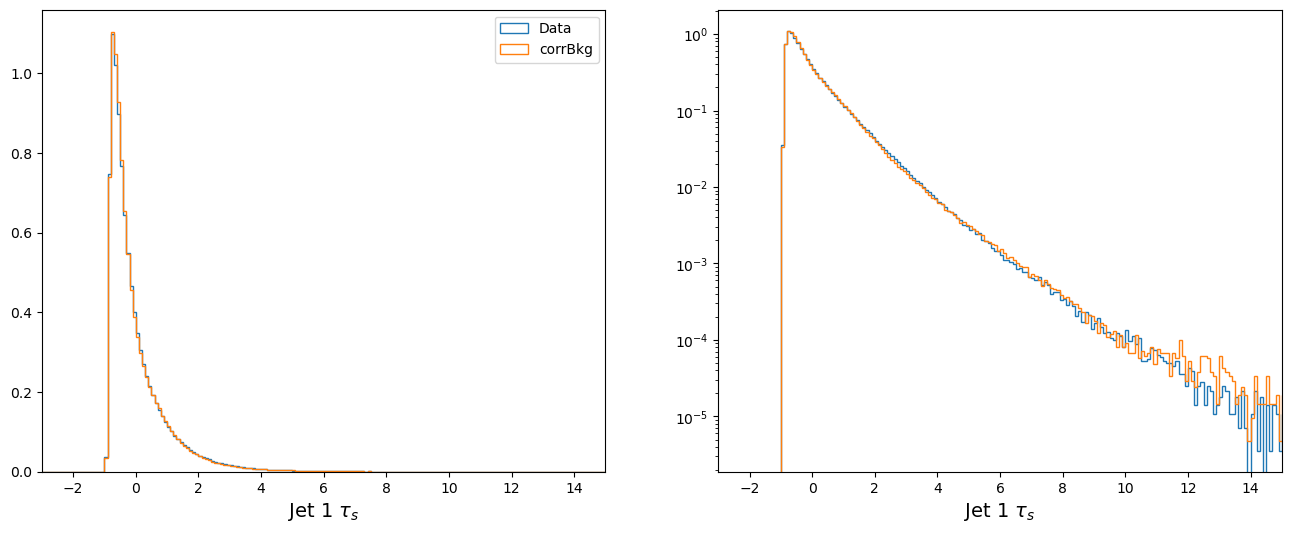

In [22]:
trainer.stepTo("tauS")
trainer.changeQuantile("tauS",makeQList(data[:,inds["tauS"]],[0.01,0.999],[10]))
trainer.changeWidth("tauS",(10,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

Current variable: tau21
---------- Training Data, tau21 ----------
Epoch 100, Loss: 0.14223675151121776
Epoch 200, Loss: 0.14072695224927959
Epoch 300, Loss: 0.14002336985998845
stopping early at epoch 303
---------- Training Bkg, tau21 ----------
Epoch 100, Loss: 0.14004475890915452
Epoch 200, Loss: 0.13787990447825887
Epoch 300, Loss: 0.1371547311655155
stopping early at epoch 369
1191  Events with bad quantiles ( 0.05702376181591236  %)
	 1094  from bkg ( 0.05237950917431412  %)
	 606  from data ( 0.029014609286685884  %)
21596  Underflow ( 1.0339925778139742  %)
21513  Overflow ( 1.030018629677349  %)


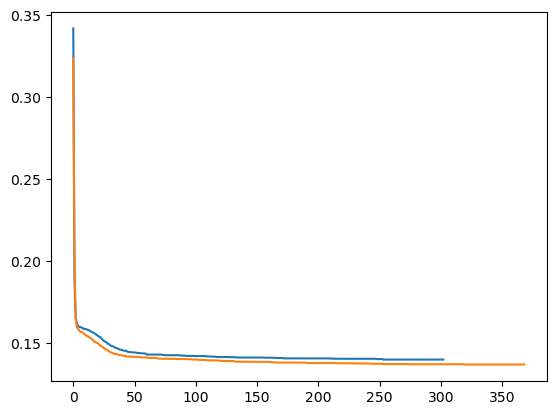

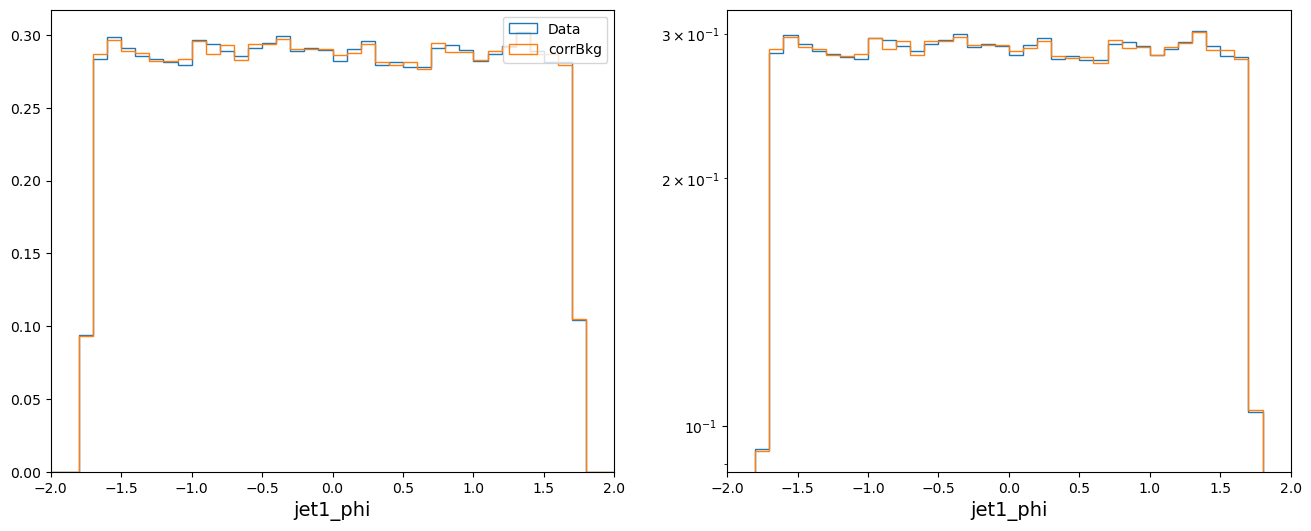

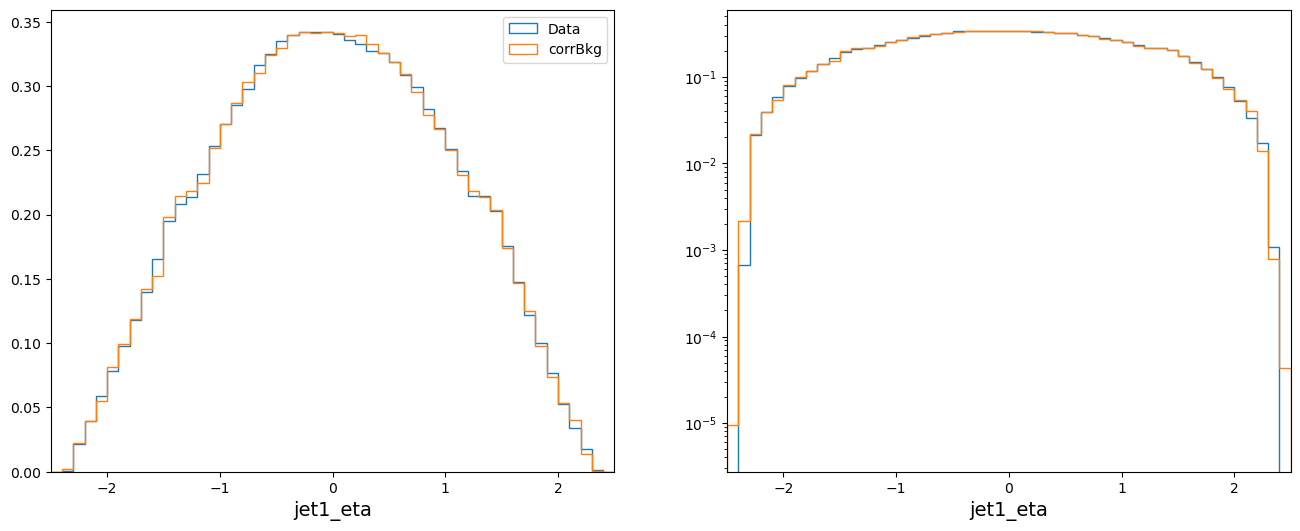

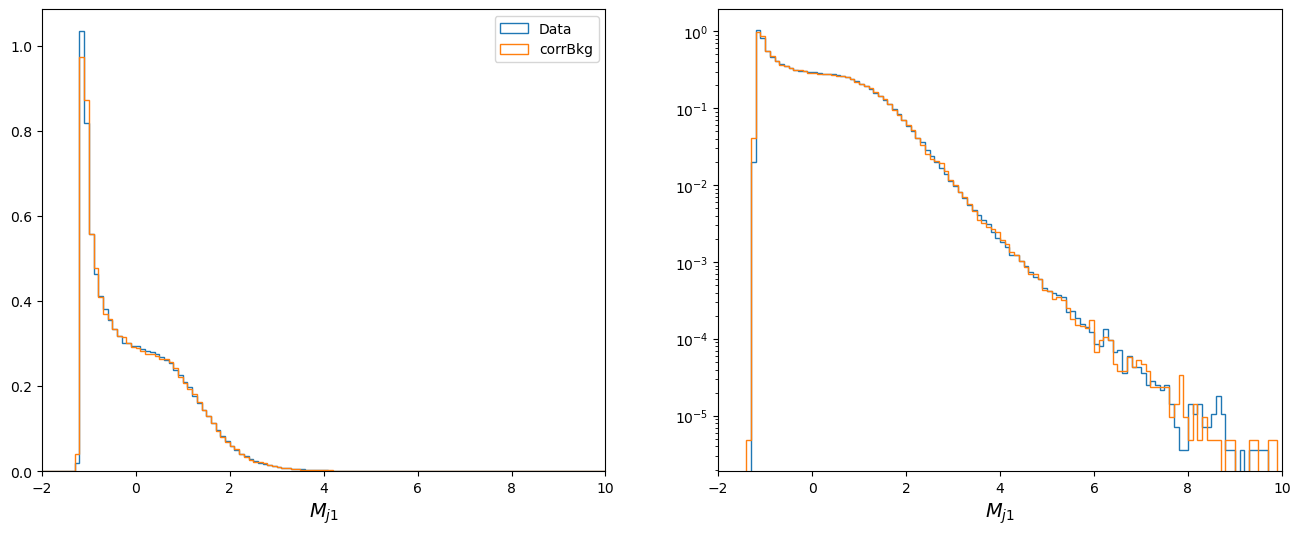

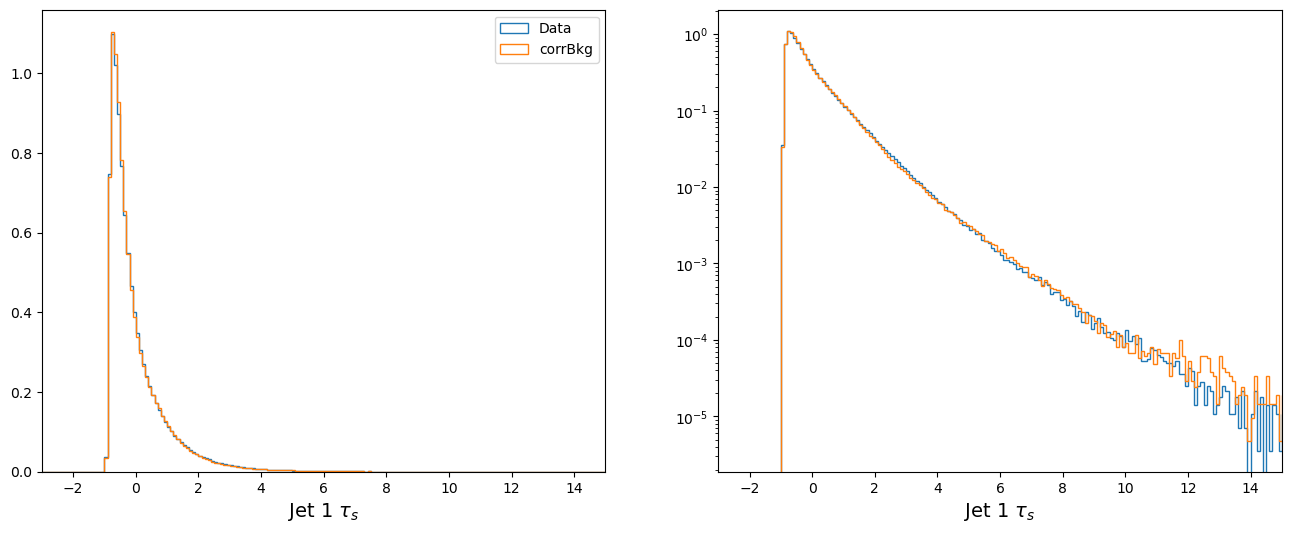

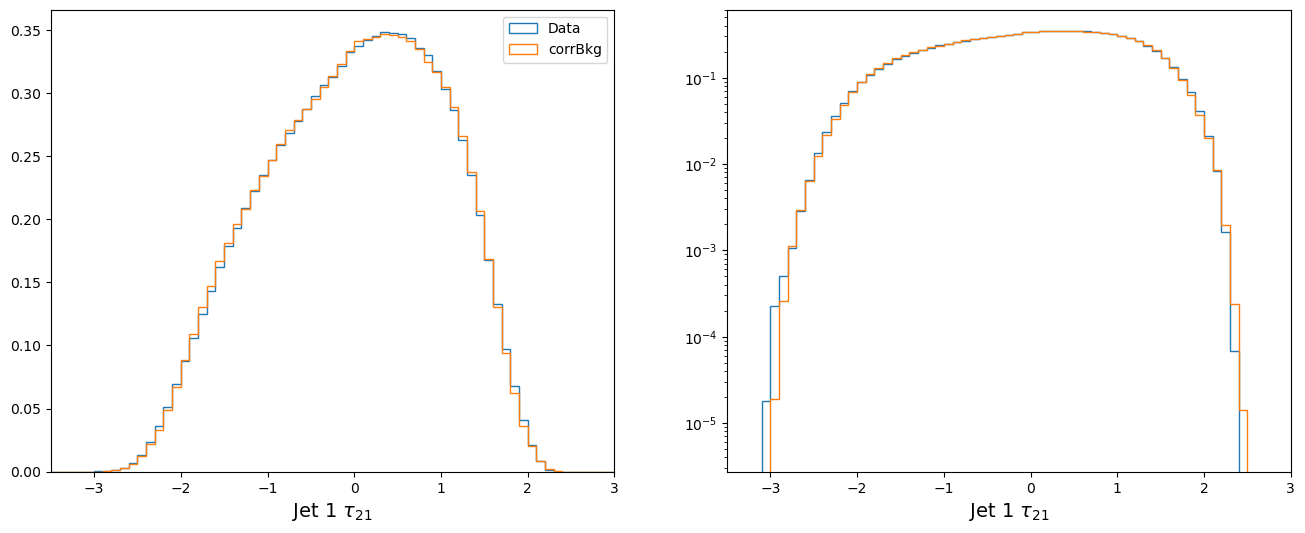

In [26]:
trainer.stepTo("tau21")
trainer.changeQuantile("tau21",makeQList(data[:,inds["tau21"]],[0.01,0.99],[20]))
trainer.changeWidth("tau21",(20,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

Current variable: tau32
---------- Training Data, tau32 ----------
Epoch 100, Loss: 0.14429783818414307
Epoch 200, Loss: 0.14295666634470577
stopping early at epoch 229
---------- Training Bkg, tau32 ----------
Epoch 100, Loss: 0.13903819159453326
Epoch 200, Loss: 0.13833980611565264
stopping early at epoch 257
285  Events with bad quantiles ( 0.01364548456552059  %)
	 197  from bkg ( 0.00943214196283353  %)
	 96  from data ( 0.004596373748385883  %)
20200  Underflow ( 0.9671536428895295  %)
115  Overflow ( 0.005506072719420589  %)


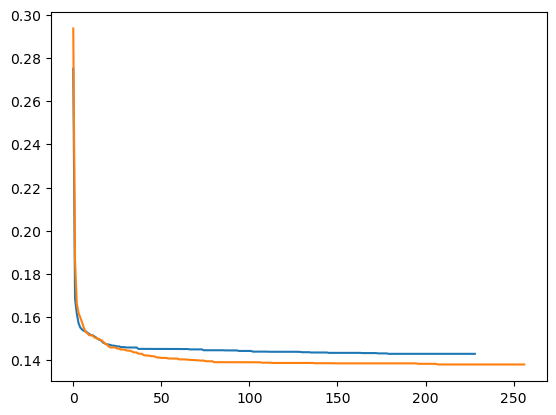

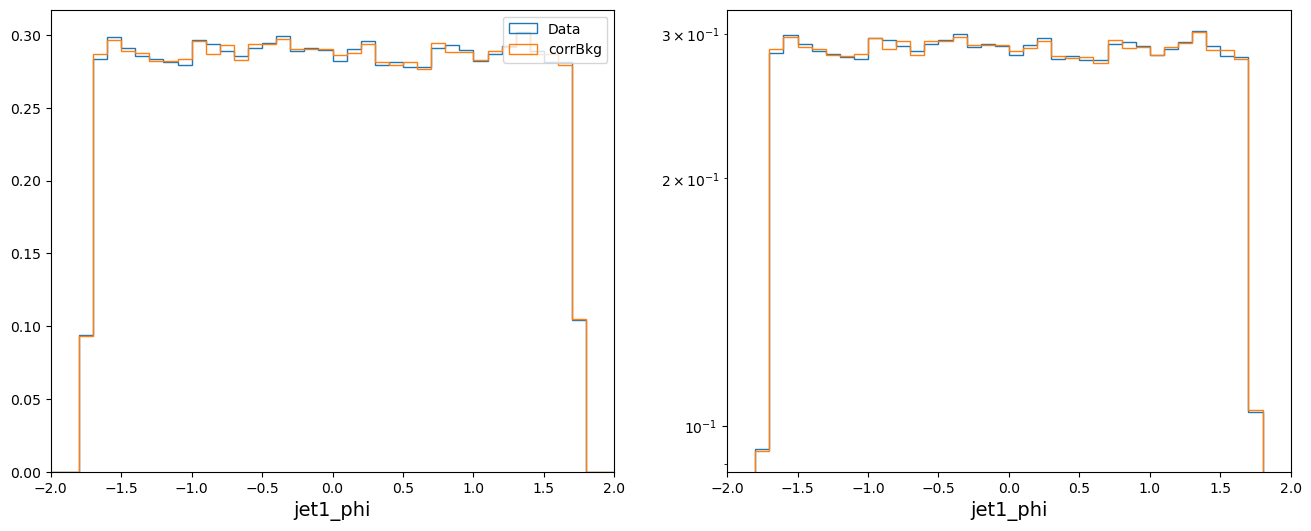

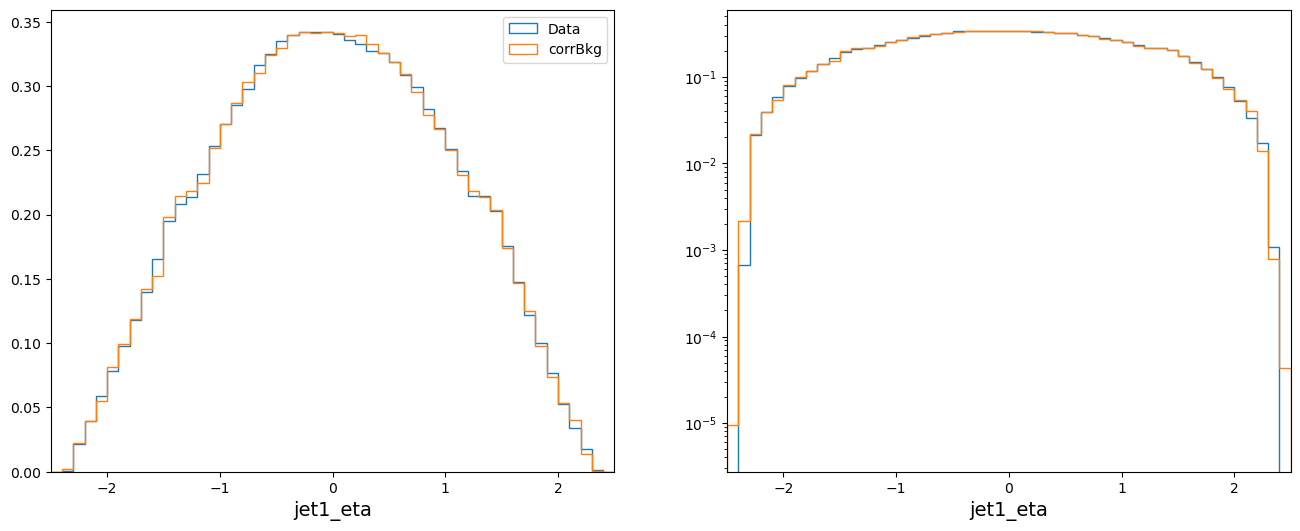

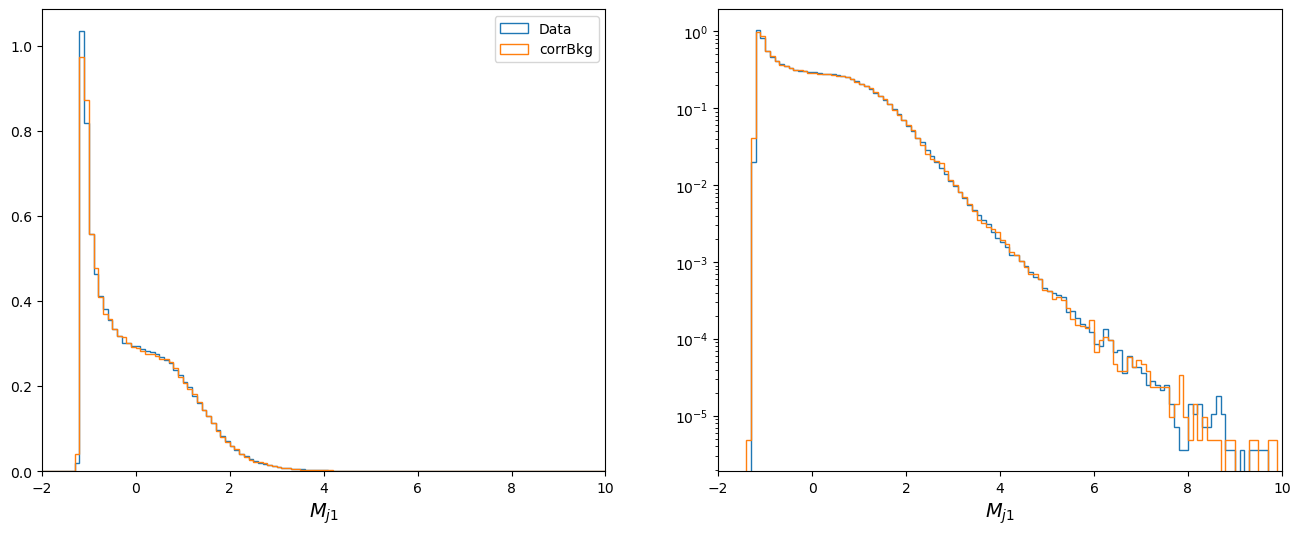

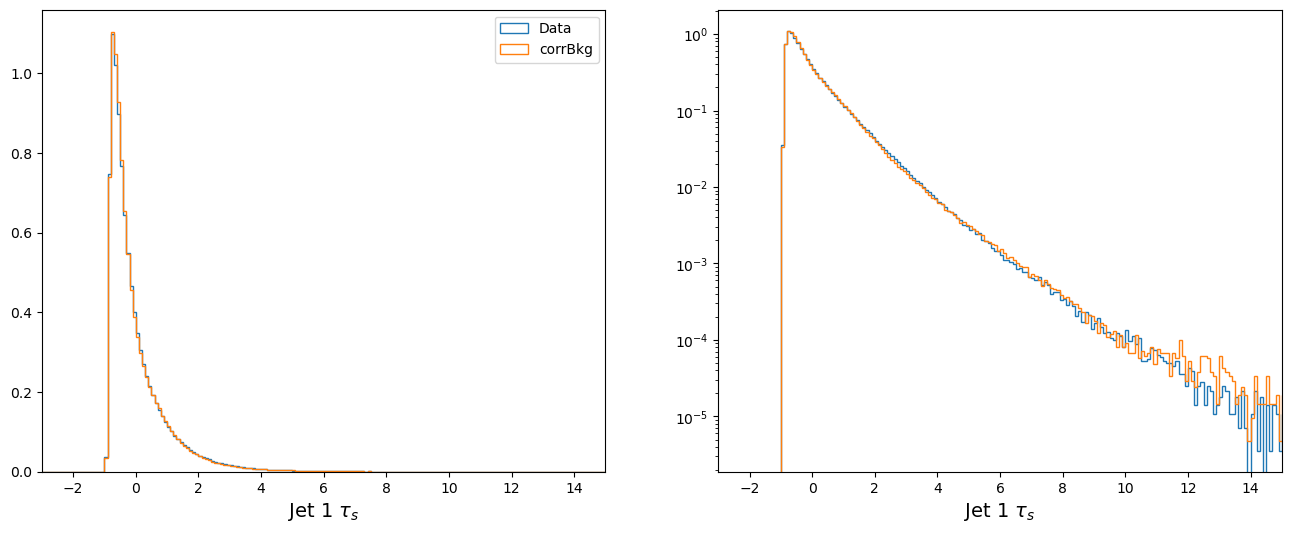

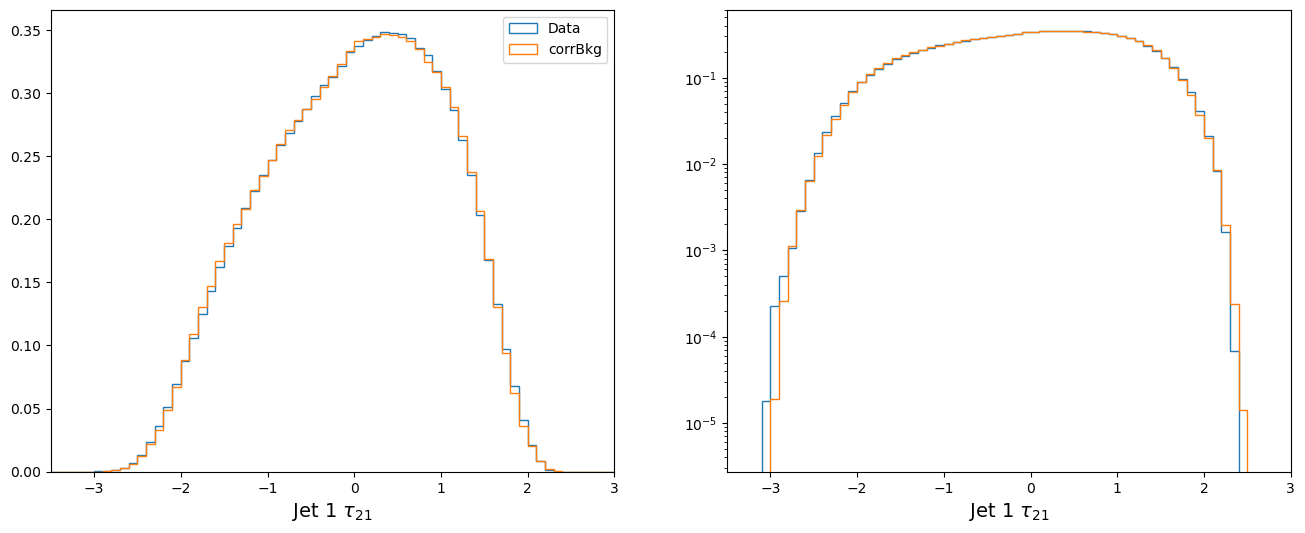

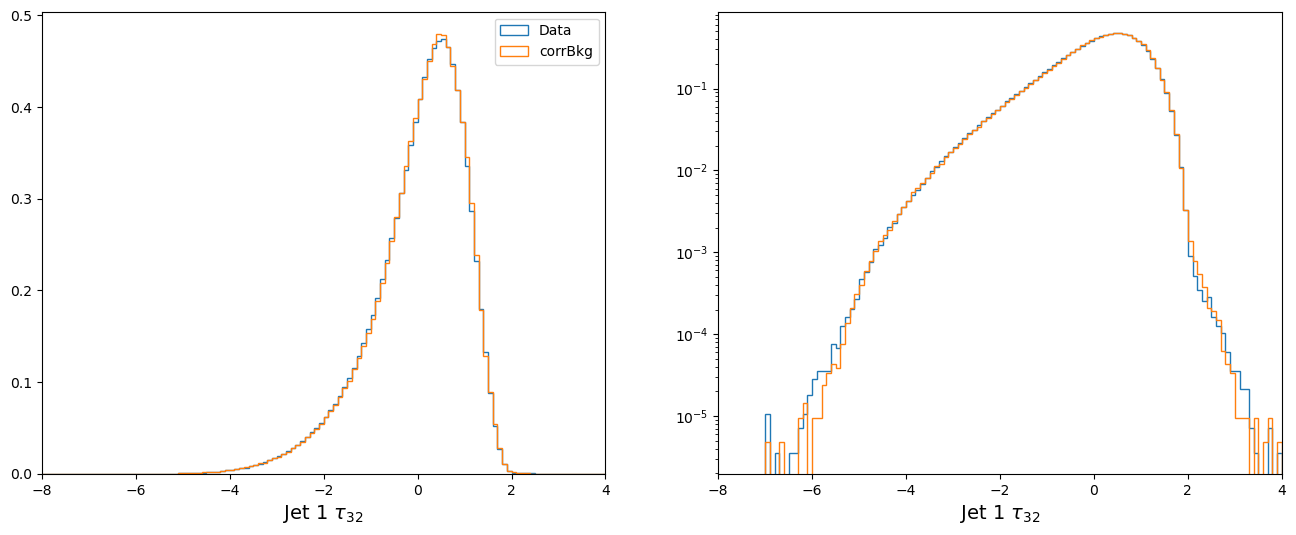

In [27]:
trainer.stepTo("tau32")
trainer.changeQuantile("tau32",makeQList(data[:,inds["tau32"]],[0.01,0.9999],[20]))
trainer.changeWidth("tau32",(20,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

Current variable: tau43
---------- Training Data, tau43 ----------
Epoch 100, Loss: 0.14207422239329118
Epoch 200, Loss: 0.14169468972382143
stopping early at epoch 223
---------- Training Bkg, tau43 ----------
Epoch 100, Loss: 0.13594184217288885
Epoch 200, Loss: 0.13493895379532234
stopping early at epoch 279
297  Events with bad quantiles ( 0.014220031284068825  %)
	 73  from bkg ( 0.003495159204501765  %)
	 238  from data ( 0.011395176584540001  %)
21514  Underflow ( 1.0300665085705614  %)
172  Overflow ( 0.008235169632524707  %)


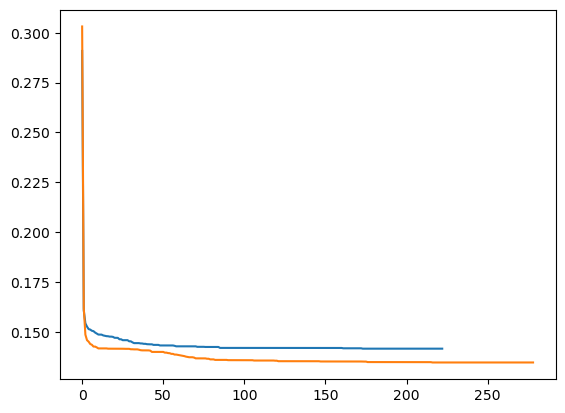

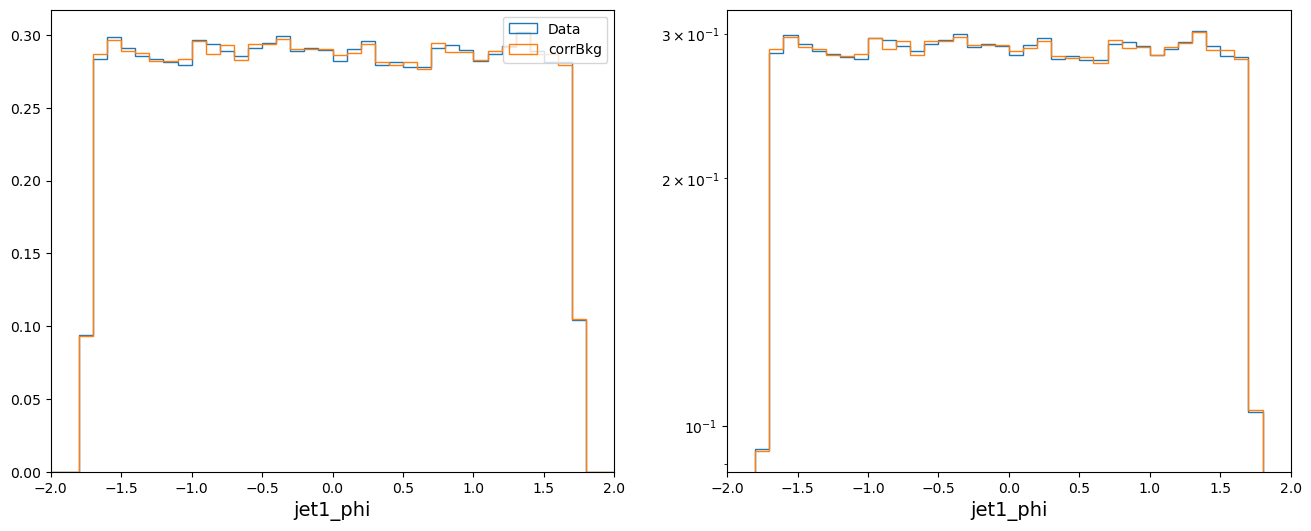

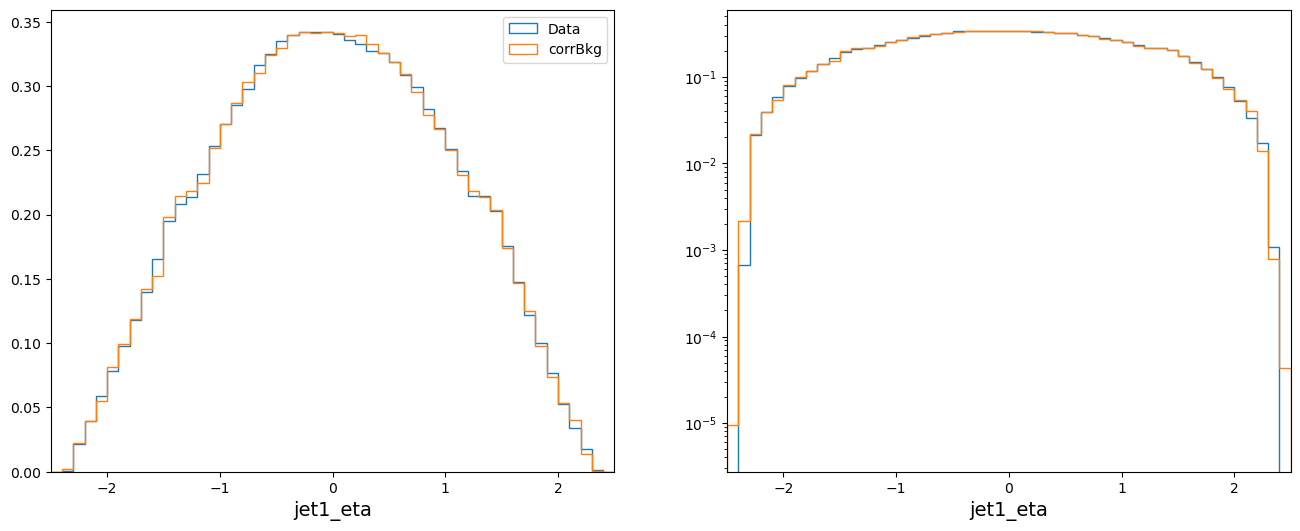

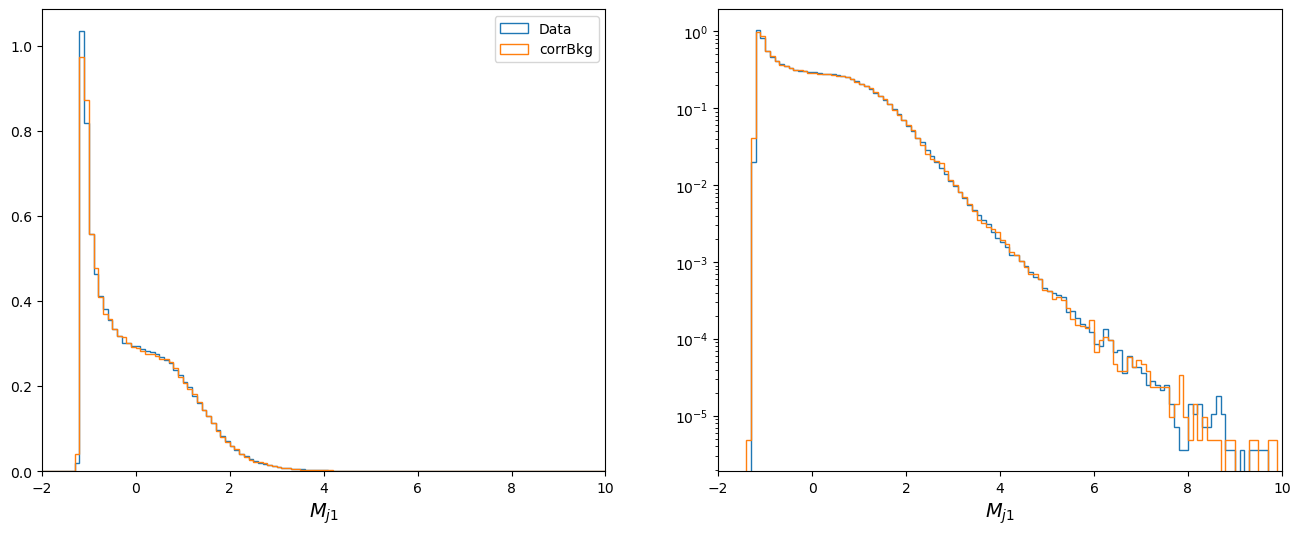

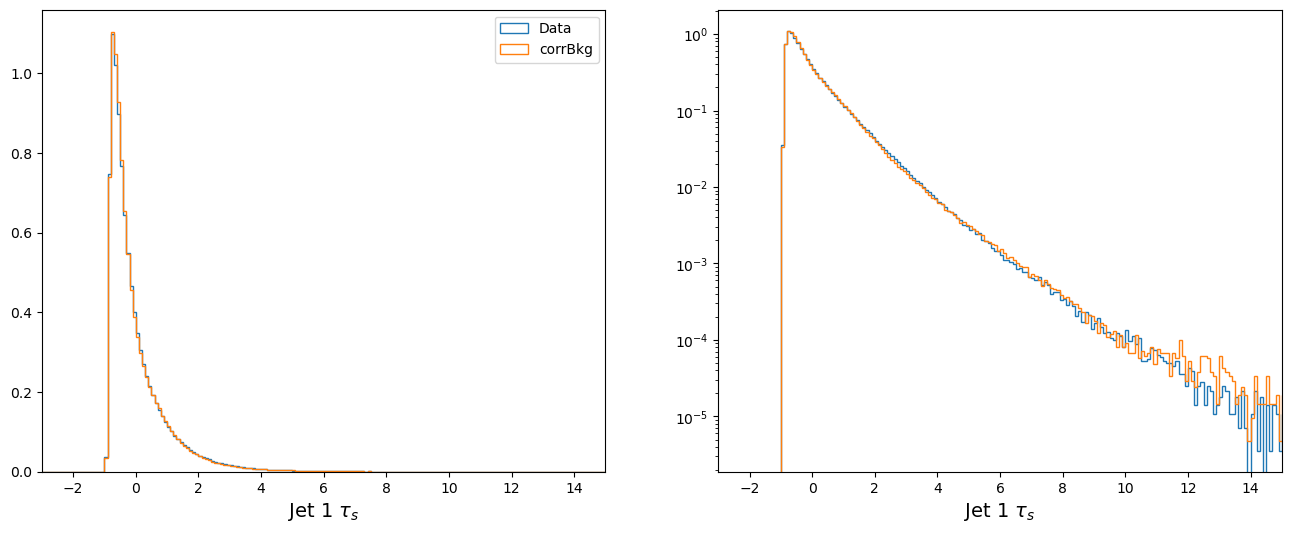

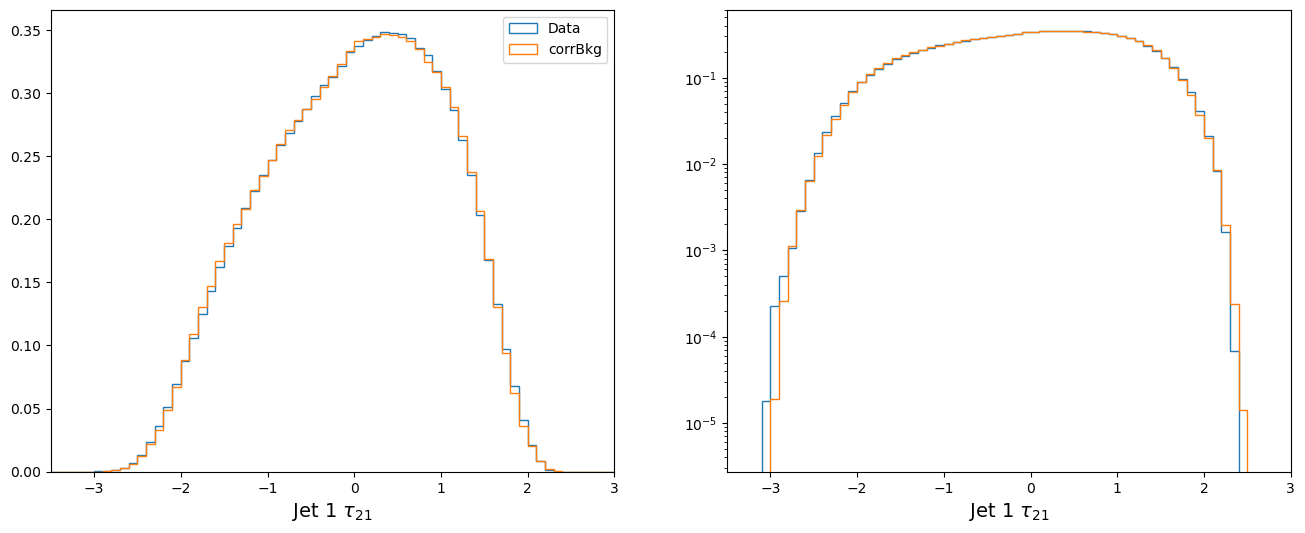

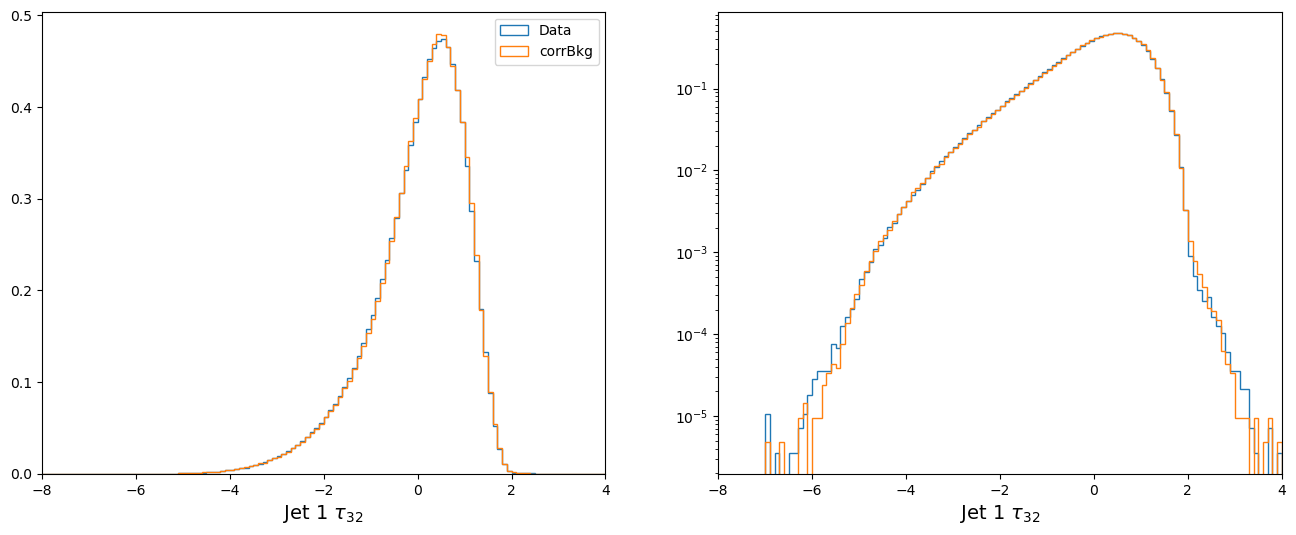

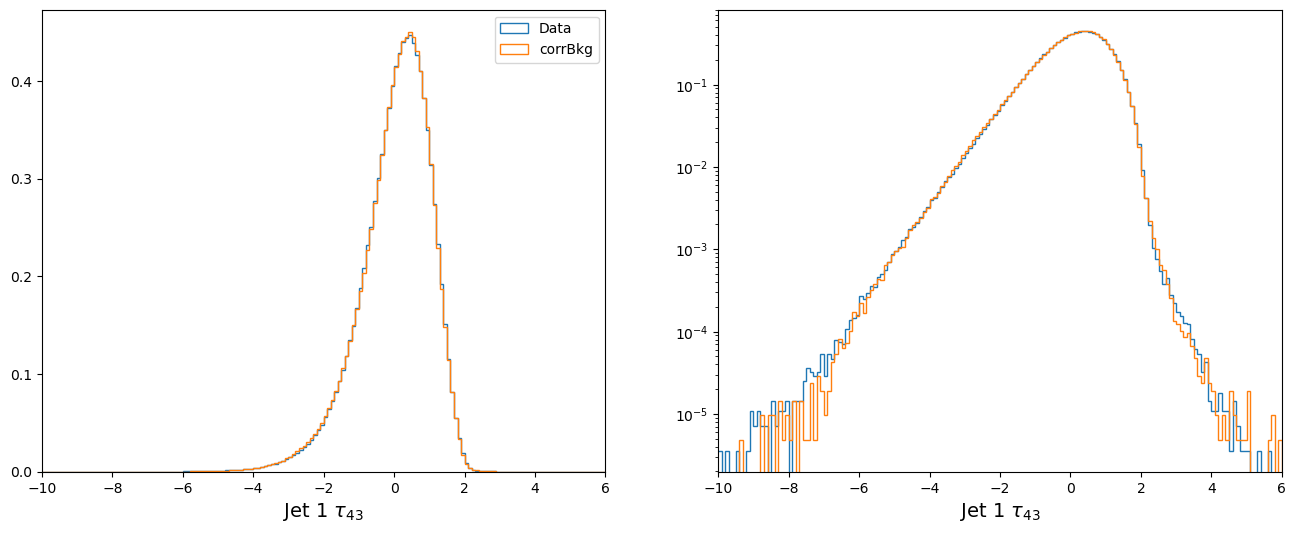

In [28]:
trainer.stepTo("tau43")
trainer.changeQuantile("tau43",makeQList(data[:,inds["tau43"]],[0.01,0.9999],[20]))
trainer.changeWidth("tau43",(20,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

In [81]:
trainer.addVariable("npf")

Current variable: npf
---------- Training Data, npf ----------
Epoch 100, Loss: 0.08975075067540432
Epoch 200, Loss: 0.08897262149328762
stopping early at epoch 275
---------- Training Bkg, npf ----------
Epoch 100, Loss: 0.0881615217680737
Epoch 200, Loss: 0.08723096717843841
stopping early at epoch 234
916  Events with bad quantiles ( 0.0438570661825153  %)
	 659  from bkg ( 0.03155219062694059  %)
	 320  from data ( 0.015321245827952943  %)
22519  Underflow ( 1.078184796248976  %)
19815  Overflow ( 0.9487202690027736  %)


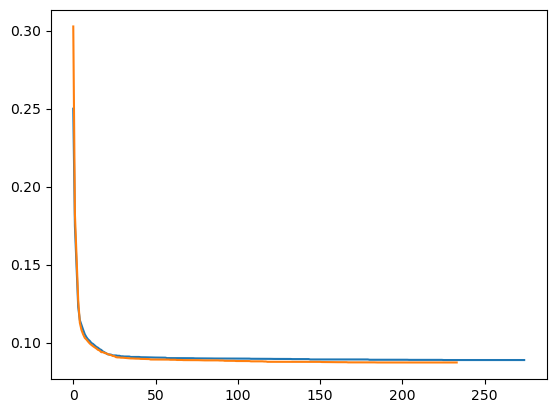

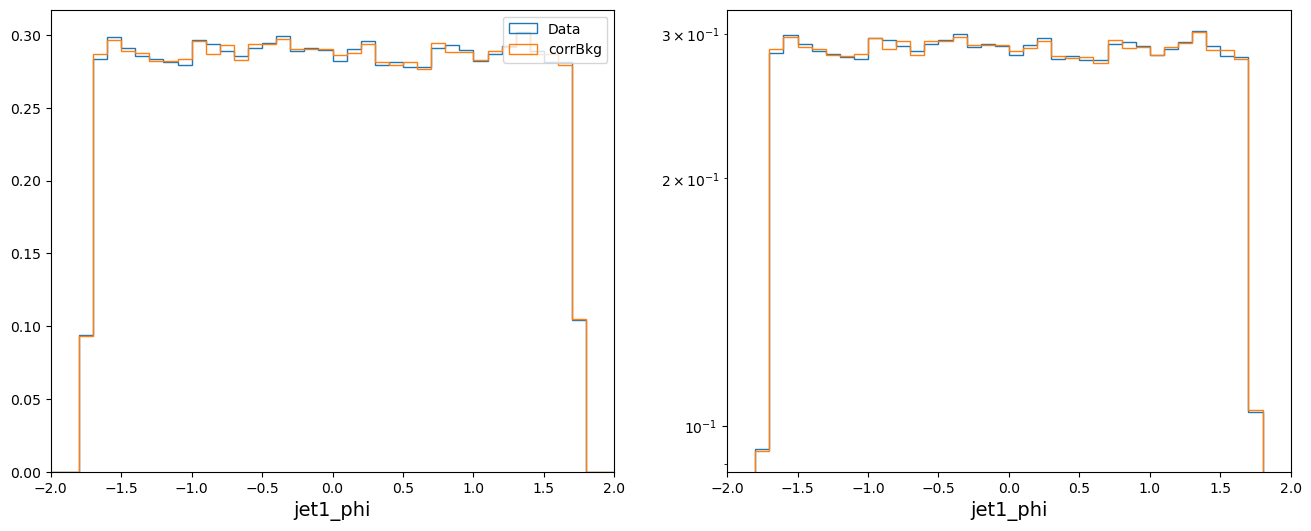

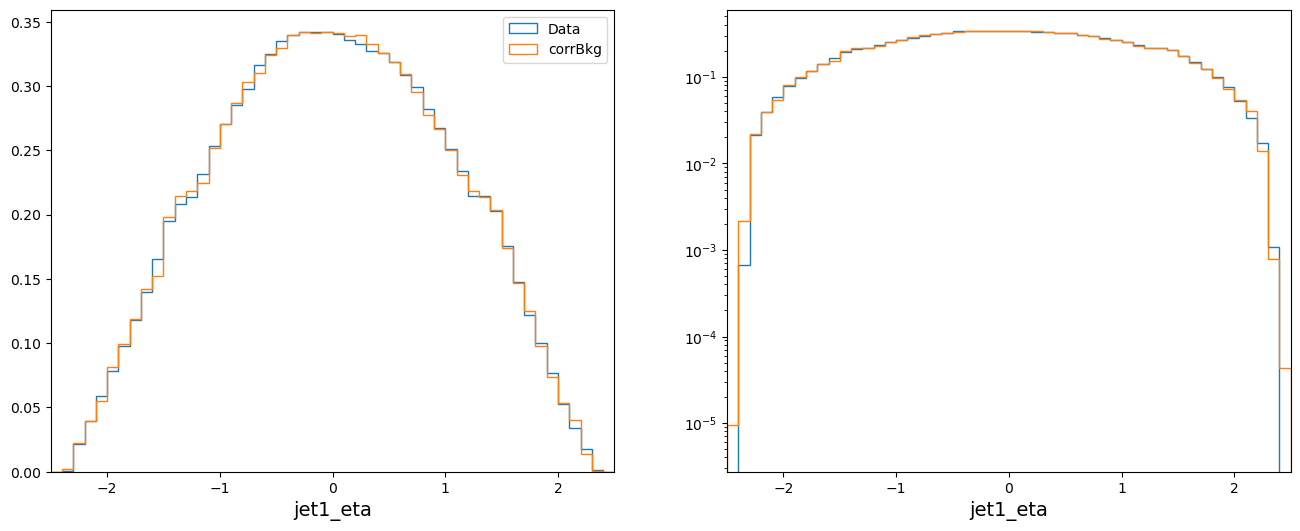

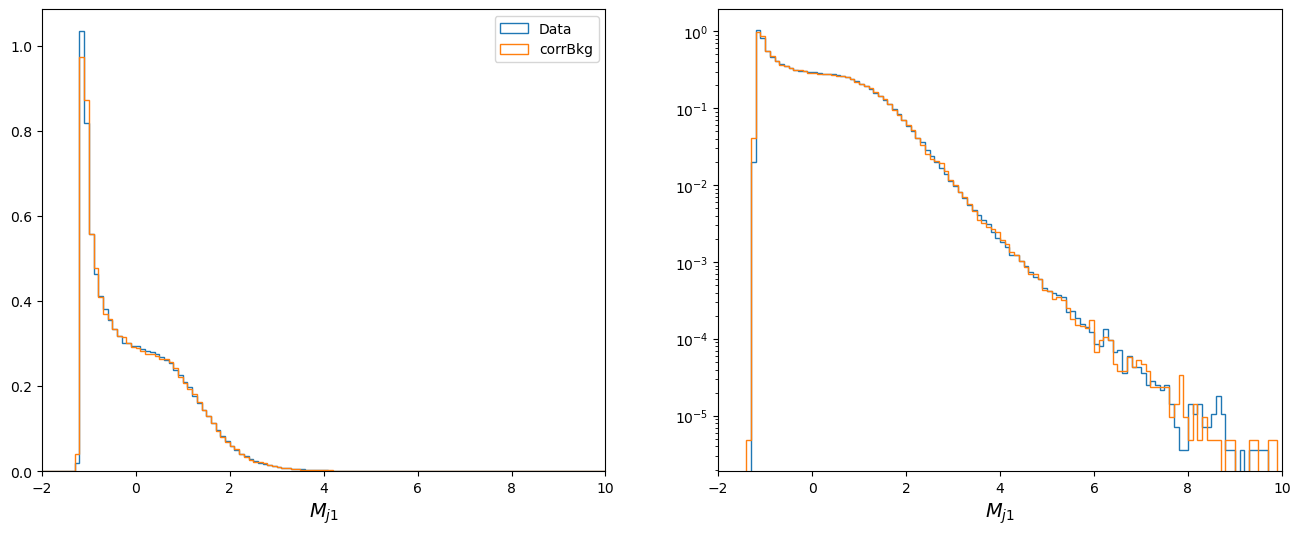

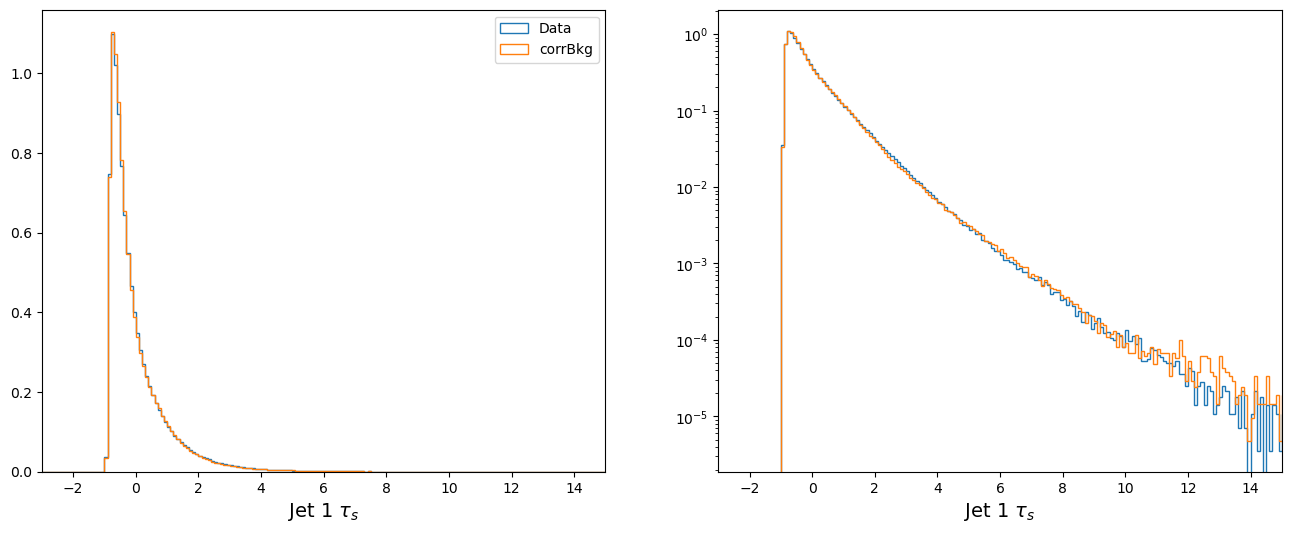

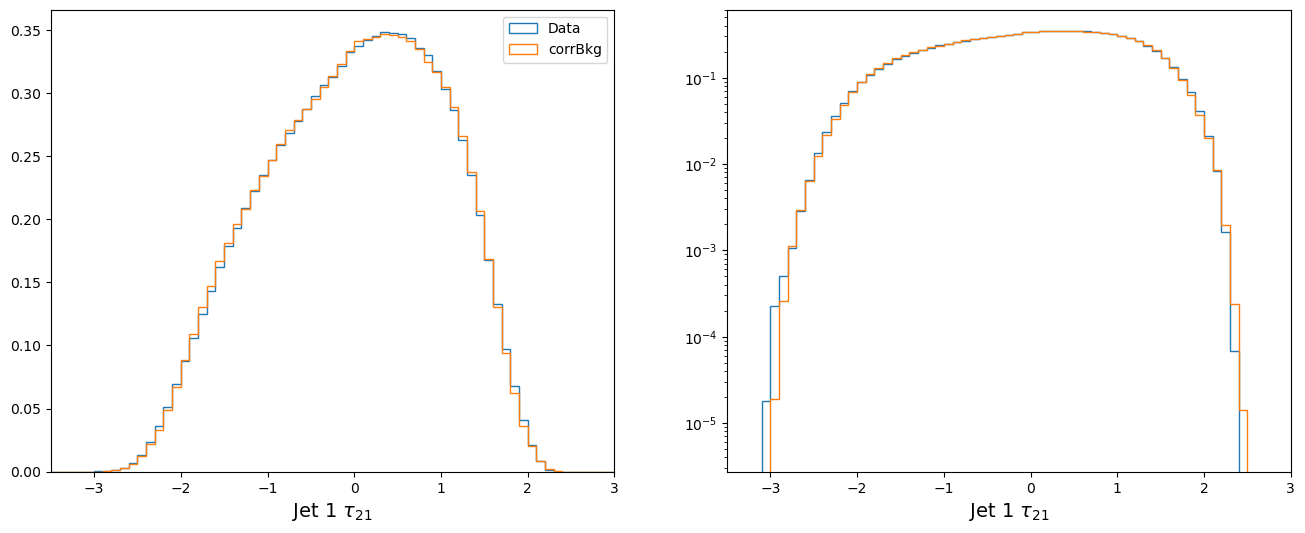

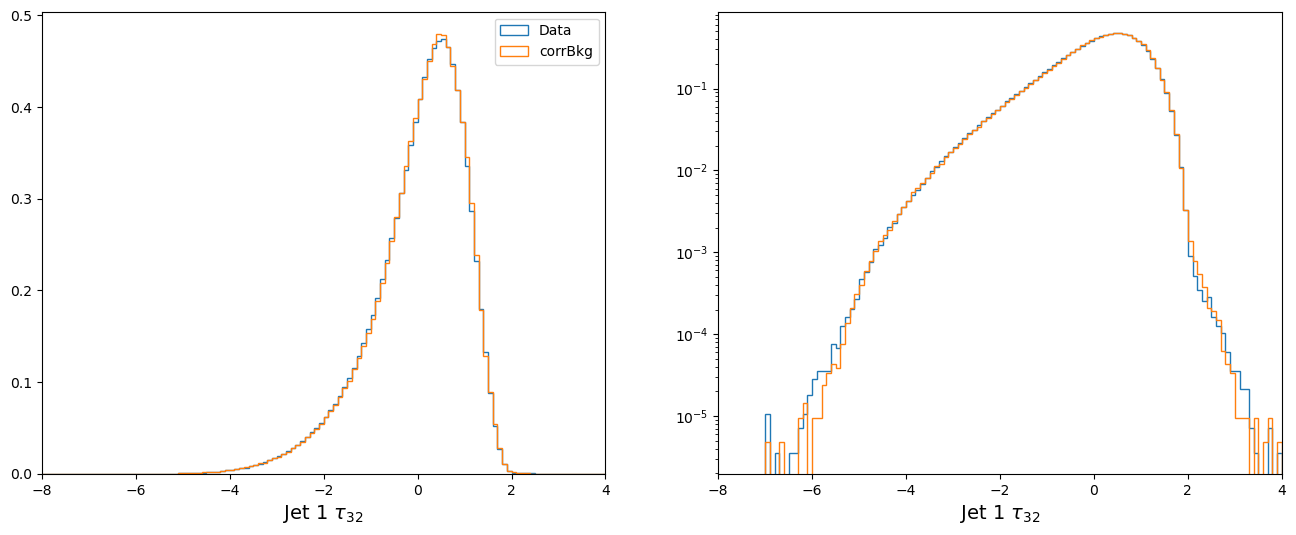

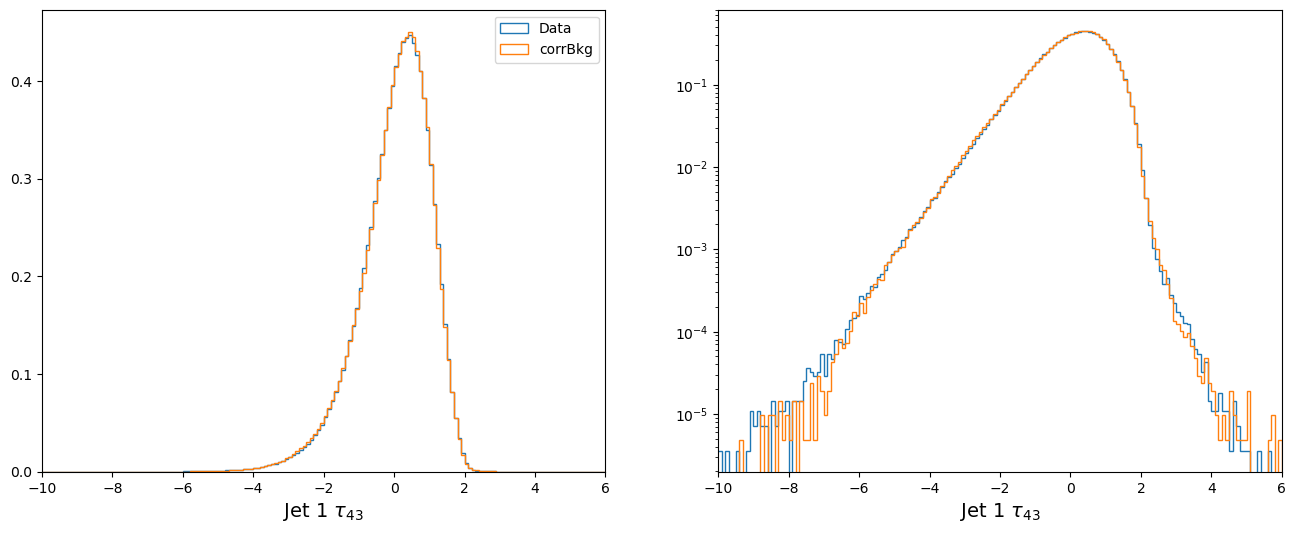

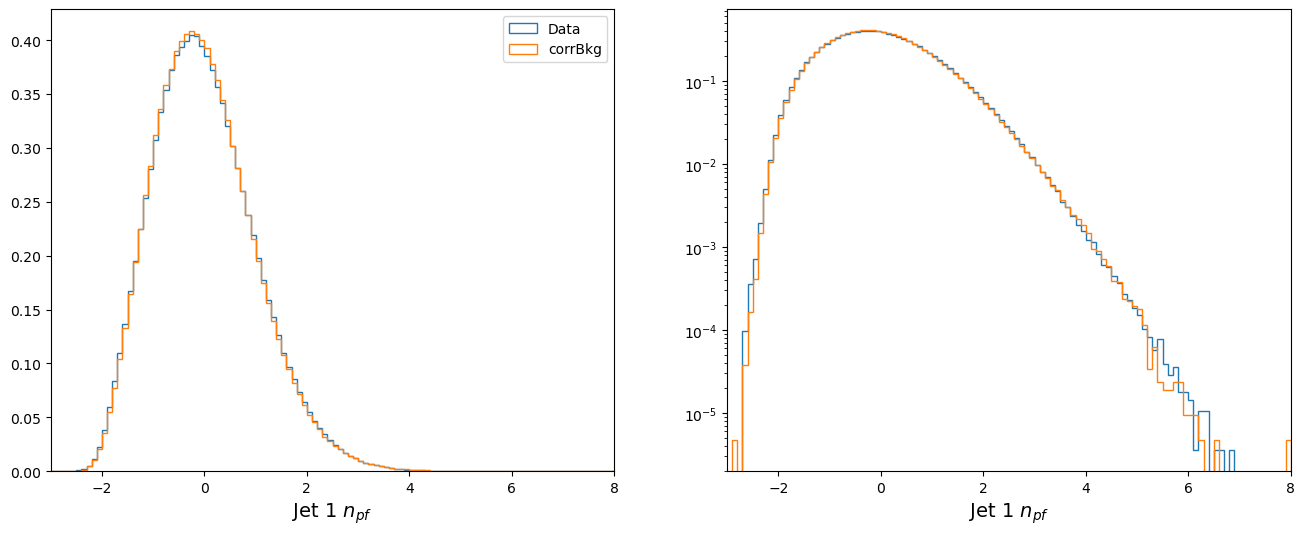

In [82]:
trainer.stepTo("npf")
trainer.changeQuantile("npf",makeQList(data[:,inds["npf"]],[0.01,0.99],[20]))
trainer.changeWidth("npf",(20,2))
trainer.trainCurrent(**kwargs)
trainer.plotCorrected()

In [83]:
import pickle
with open("QR_models/jet1_correctors/jet1_trainer.pkl","wb") as f:
    pickle.dump(trainer,f)

In [84]:
for i,v in enumerate(trainer.varOrder):
    np.save("QR_models/jet1_correctors/corr_{0}_bkg_{1}.npy".format(i,v),trainer.corrBkg_dict[trainer.varDict[v]])

In [85]:
for i in range(len(trainer.data_models)):
    torch.save(trainer.data_models[i],"QR_models/jet1_correctors/data_model_{0}_{1}.pt".format(i+1,trainer.varOrder[i+1]))
    torch.save(trainer.bkg_models[i],"QR_models/jet1_correctors/bkg_model_{0}_{1}.pt".format(i+1,trainer.varOrder[i+1]))

In [90]:
import json
with open('QR_models/jet1_correctors/train_kwargs.json',"w") as f:
    f.write(json.dumps(kwargs,indent=4))